# `pyweatherfiles` Tutorial: A Case Study on TMY Generation, EPW Conversion and Climate-Trend Analysis for Seville and Madrid

This notebook is the computational supplementary material for the manuscript `Manuscript_TMY_v02.md` (repository root). It reproduces, end to end and using **real, non-synthetic data** for two Spanish provincial capitals (Seville and Madrid), the complete workflow implemented by the **`pyweatherfiles`** package:

1. **Typical Meteorological Year (TMY) generation** -- the Sandia/TMY3 algorithm (`pyweatherfiles.tmy.TMYGenerator`), executed both **step by step** (calling every individual `sandia_step_*` method, together with the full validation and plotting API) and through the **single-call** convenience method `generate_tmy()`, so that both usage styles are demonstrated and cross-checked against each other.
2. **Conversion to EnergyPlus Weather (EPW) format** of the three climate scenarios used in the manuscript's simulation battery: the *historical* multi-year hourly series (`HourlyEPWConverter`), the generated *typical year* (same converter, applied to the TMY output), and the official Spanish *regulatory* reference file in `.met` format (`met_epw_converter.convert_met_to_epw`).
3. **Degree-hours and climate-trend analysis** (`pyweatherfiles.degree_hours`), reproducing the heating/cooling degree-hour indicators and the boxplot-style multi-year trend figure of Section 3.1 of the manuscript, computed here for the two case-study cities.

```{note}
This notebook is intentionally verbose: every call that produces its own output (a printed diagnostic, a table, or a figure) is placed in its own code cell, and every code cell is preceded by a short explanation of the arguments used and their role in the workflow. This mirrors, and extends to the full 7-step TMY pipeline and to both study cities, the style of the standalone script `generating epws seville.py` in the repository root.
```

```{tip}
For the complete technical reference of every class, method and formula used below, see the Sphinx documentation site (when viewed as part of the documentation), or, equivalently, `README.md` / `README_ES.md` in the repository root.
```

## Notebook outline

- **Part 0 -- Setup and input data.** Locate the repository, define the input files of the two case-study cities, and run a pre-flight check of their column names.
- **Part 1 -- Typical Meteorological Year generation.**
  - Part 1.1: Seville, **step by step** (all seven Sandia steps, with the full validation and plotting API).
  - Part 1.2: Seville, **single-call** generation (`generate_tmy()`), cross-checked against the step-by-step result.
  - Part 1.3: Madrid, single-call generation (condensed), demonstrating the same workflow on a second location with a different column layout.
- **Part 2 -- Conversion to EPW format.** The three climate scenarios of the manuscript (historical, typical-year, regulatory), for both cities.
- **Part 3 -- Degree-hours and climate-trend analysis.** Heating/cooling degree-hours, per-city and global (fixed-effects) linear trends, and the manuscript-style boxplot figure, for Seville and Madrid.
- **Part 4 -- Conclusions and further reading.**

```{note}
This is a large, multi-session tutorial under active development. Code cells marked with `# TODO(dev): ...` are placeholders that will be filled in incrementally in follow-up passes; the surrounding Markdown text already documents the intended arguments and workflow for each step, so that development can proceed cell by cell without revisiting the overall design.
```

## Part 0 -- Setup and input data

The two case-study cities are Seville and Madrid -- the same locations used in `generating epws seville.py` and in the manuscript's simulation battery. All of their input files live in `data/`, right next to this notebook (see `docs/source/jupyter_notebooks/` in the repository) so the whole case study is self-contained and version-controlled: the multi-year hourly series (`.xlsx`), the official CTE regulatory reference file (`.met`), and an EPW template used only to supply header metadata (latitude, longitude, elevation, time zone).

| City    | Hourly series (`.xlsx`)                        | Regulatory file (`.met`) | EPW template                  |
|---------|-------------------------------------------------|---------------------------|---------------------------------|
| Seville | `Seville_hourly_data.xlsx`   | `seville.met`           | `ESP_Sevilla.083910_SWEC.epw`    |
| Madrid  | `Madrid_hourly_data.xlsx`    | `madrid.met`            | `ESP_Madrid.082210_IWEC.epw`     |

Seville is treated as the *reference* city (its column mapping and workflow follow `generating epws seville.py` exactly), while Madrid is used throughout to demonstrate that the same tools generalise to a second location, potentially with a different column layout in the source file.

In [1]:
import os
import sys

NOTEBOOK_DIR = os.getcwd()


def find_repo_root(start):
    path = os.path.abspath(start)
    while True:
        if os.path.exists(os.path.join(path, 'pyproject.toml')):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError('Could not locate the repository root (pyproject.toml not found).')
        path = parent


REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
sys.path.insert(0, REPO_ROOT)
print('Notebook directory (holds data/ and case_study_output/):', NOTEBOOK_DIR)
print('Repository root (only used to import pyweatherfiles from source):', REPO_ROOT)

Notebook directory (holds data/ and case_study_output/): D:\Python\pyweatherfiles\docs\source\jupyter_notebooks
Repository root (only used to import pyweatherfiles from source): D:\Python\pyweatherfiles


### Input files and output directory

We collect each city's file paths in a small dictionary (`SEVILLE`, `MADRID`) so that every later cell can refer to `SEVILLE['xlsx']`, `SEVILLE['met']`, `SEVILLE['base_epw']`, etc., instead of repeating literal paths. A dedicated scratch folder, `case_study_output/` (created next to this notebook, git-ignored), collects every artefact generated by this notebook (TMY exports, EPW files, degree-hour tables, figures) without touching the tracked input data under `data/`.

In [2]:
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')

SEVILLE = {
    'label': 'Seville',
    'xlsx': os.path.join(DATA_DIR, 'Seville_hourly_data.xlsx'),
    'met': os.path.join(DATA_DIR, 'seville.met'),
    'base_epw': os.path.join(DATA_DIR, 'ESP_Sevilla.083910_SWEC.epw'),
}
MADRID = {
    'label': 'Madrid',
    'xlsx': os.path.join(DATA_DIR, 'Madrid_hourly_data.xlsx'),
    'met': os.path.join(DATA_DIR, 'madrid.met'),
    'base_epw': os.path.join(DATA_DIR, 'ESP_Madrid.082210_IWEC.epw'),
}
for city in (SEVILLE, MADRID):
    print(f"{city['label']:8s} xlsx={os.path.basename(city['xlsx'])}  "
          f"met={os.path.basename(city['met'])}  base_epw={os.path.basename(city['base_epw'])}")

Seville  xlsx=Sevilla_Definitivo_para_convertir_a_epw.xlsx  met=sevilla_SP.met  base_epw=ESP_Sevilla.083910_SWEC.epw
Madrid   xlsx=Madrid_Definitivo_para_convertir_a_epw.xlsx  met=madrid_SP.met  base_epw=ESP_Madrid.082210_IWEC.epw


In [3]:
OUT_DIR = os.path.join(NOTEBOOK_DIR, 'case_study_output')
os.makedirs(OUT_DIR, exist_ok=True)
print('Tutorial output folder:', OUT_DIR)

Tutorial output folder: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output


### Pre-flight check of the input columns (`TMYGenerator.check_input_expectations`)

Before instantiating any `TMYGenerator`, it is good practice to verify that the expected variables (`time`, dry-bulb temperature, dew-point temperature, wind speed, global horizontal irradiance, direct normal irradiance) can be found in the source file, under whichever column names it happens to use. `check_input_expectations` is a **`@staticmethod`** -- it is called directly on the class, without creating an instance -- and it prints a ready-to-use `column_mapping` snippet for any variable it cannot find automatically.

In [4]:
from pyweatherfiles import tmy

tmy.TMYGenerator.check_input_expectations(SEVILLE['xlsx'], weighting_method='sandia', data_frequency='hourly')

--- Analyzing 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Sevilla_Definitivo_para_convertir_a_epw.xlsx' for sandia method (hourly) ---
Found columns (after mapping): ['time', 'Dry-bulb temperature', 'Dew Point temperature', 'Relative Humidity', 'Wind Direction', 'Wind Speed', 'Pressure', 'Global Horizontal Irradiance ', 'Beam Horizontal Irradiance ', 'Diffuse Horizontal Irradiance', 'Beam Normal Irradiance ', 'Total Cloud Cover', 'N', 'Emissivity clear sky', 'Emissivity sky', 'IRh', 'Tsky']

Expected Variables: ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI']
Ref: 'time' column found and format looks valid.

Result: Missing exact matches for: ['T_air', 'T_dew', 'Wind_speed', 'GHI']
You likely need to provide or update a `column_mapping` dictionary.
Example structure:
column_mapping = {
    '<your_file_column_for_T_air>': 'T_air',
    '<your_file_column_for_T_dew>': 'T_dew',
    '<your_file_column_for_Wind_speed>': 'Wind_speed',
    '<your_file_column_for_GHI>': 'GHI',
}

{'found_columns': ['time',
  'Dry-bulb temperature',
  'Dew Point temperature',
  'Relative Humidity',
  'Wind Direction',
  'Wind Speed',
  'Pressure',
  'Global Horizontal Irradiance ',
  'Beam Horizontal Irradiance ',
  'Diffuse Horizontal Irradiance',
  'Beam Normal Irradiance ',
  'Total Cloud Cover',
  'N',
  'Emissivity clear sky',
  'Emissivity sky',
  'IRh',
  'Tsky'],
 'expected_variables': ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'missing_exact': ['T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'time_valid': True}

In [5]:
tmy.TMYGenerator.check_input_expectations(MADRID['xlsx'], weighting_method='sandia', data_frequency='hourly')

--- Analyzing 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Madrid_Definitivo_para_convertir_a_epw.xlsx' for sandia method (hourly) ---
Found columns (after mapping): ['time', 'Dry-bulb temperature', 'Dew Point temperature', 'Relative Humidity', 'Wind Direction', 'Wind Speed', 'Pressure', 'Global Horizontal Irradiance ', 'Beam Horizontal Irradiance ', 'Diffuse Horizontal Irradiance', 'Beam Normal Irradiance ', 'Total Cloud Cover', 'N', 'Emissivity clear sky', 'Emissivity sky', 'IRh', 'Tsky']

Expected Variables: ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI']
Ref: 'time' column found and format looks valid.

Result: Missing exact matches for: ['T_air', 'T_dew', 'Wind_speed', 'GHI']
You likely need to provide or update a `column_mapping` dictionary.
Example structure:
column_mapping = {
    '<your_file_column_for_T_air>': 'T_air',
    '<your_file_column_for_T_dew>': 'T_dew',
    '<your_file_column_for_Wind_speed>': 'Wind_speed',
    '<your_file_column_for_GHI>': 'GHI',
}


{'found_columns': ['time',
  'Dry-bulb temperature',
  'Dew Point temperature',
  'Relative Humidity',
  'Wind Direction',
  'Wind Speed',
  'Pressure',
  'Global Horizontal Irradiance ',
  'Beam Horizontal Irradiance ',
  'Diffuse Horizontal Irradiance',
  'Beam Normal Irradiance ',
  'Total Cloud Cover',
  'N',
  'Emissivity clear sky',
  'Emissivity sky',
  'IRh',
  'Tsky'],
 'expected_variables': ['time', 'T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'missing_exact': ['T_air', 'T_dew', 'Wind_speed', 'GHI'],
 'time_valid': True}

## Part 1 -- Typical Meteorological Year generation

`pyweatherfiles.tmy.TMYGenerator` implements the Sandia/TMY3 selection algorithm described in Section 2.2.1 of the manuscript, structured as seven explicit, individually auditable steps:

| Step  | Name                                     | Method                                    |
|-------|-------------------------------------------|---------------------------------------------|
| 1     | Data loading and preparation               | `sandia_step_1_load_and_prepare`             |
| 2     | Finkelstein-Schafer candidate selection    | `sandia_step_2_select_candidates_fs`         |
| 3     | Proximity re-ranking                       | `sandia_step_3_proximity_ranking`            |
| 4-5   | Persistence filtering and final selection  | `sandia_step_4_and_5_apply_persistence`      |
| 6     | Raw TMY assembly                           | `sandia_step_6_assemble_tmy`                  |
| 7     | Junction smoothing                          | `sandia_step_7_smooth_junctions`             |

`generate_tmy()` is a convenience method that simply calls these seven methods in order; calling them individually -- as Part 1.1 does for Seville -- additionally allows inspecting and plotting the intermediate state after every step, which is useful both for teaching purposes and for auditing a specific TMY (the audit trail referred to in Section 2.2.2 of the manuscript).

```{note}
Part 1.1 (Seville) exercises **every** public method of `TMYGenerator` -- all seven `sandia_step_*` methods plus the full `validate_*`/`plot_*` diagnostic API -- as a complete tour of the tool. Part 1.2 repeats the Seville generation with the single-call `generate_tmy()` method and cross-checks that it reproduces the step-by-step result. Part 1.3 applies the single-call method to Madrid only, keeping the notebook a manageable length while still demonstrating the workflow on a second location.
```

### Part 1.1 -- Seville: step-by-step generation

We first instantiate a `TMYGenerator` **without** running any step yet -- the constructor only validates arguments and prepares default weights, it loads nothing. The column-mapping arguments (`datetime_col`, `col_temp`, `col_dew`, `col_wind`, `col_ghi`, `col_dni`) repeat exactly the header names used in `generating epws seville.py`, since Seville's hourly file was produced by the same data-integration pipeline described in Section 2.1 of the manuscript. `cdf_method='daily'` selects candidate months from daily aggregates (fast; recommended for long, multi-decade records), while `hourly_file_path` points at the same file so that Steps 6-7 (assembly and smoothing) still operate at full hourly resolution. `weighting_method='sandia'` reproduces the original Sandia weighting scheme of Table 2 of the manuscript (as opposed to `'tmy3'`, which redistributes solar weight towards DNI). `save_validation_dfs=True` retains every intermediate validation table for later inspection, and `save_session=False` avoids writing a `.pkl`/`.json` session file for this particular exploratory run (Part 1.2's single-call run keeps the default `save_session=True` instead, for full reproducibility).

In [6]:
seville_step = tmy.TMYGenerator(
    file_path=SEVILLE['xlsx'],
    cdf_method='daily',
    data_frequency='hourly',
    hourly_file_path=SEVILLE['xlsx'],
    weighting_method='sandia',
    save_validation_dfs=True,
    save_session=False,
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

Using 'hazen' plotting position for CDF calculation.


#### Step 1 -- Data loading and preparation (`sandia_step_1_load_and_prepare`)

This step resamples the source series to a strict hourly grid, clips residual negative GHI/DNI/wind-speed values to zero, and computes the daily aggregates required by the weighting scheme (mean/max/min dry-bulb and dew-point temperature, mean/max wind speed, daily GHI sum). It populates `self.df_hourly` and `self.df_daily`, and requires a minimum of five complete years of data.

In [7]:
seville_step.sandia_step_1_load_and_prepare()

Loading and preparing data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Sevilla_Definitivo_para_convertir_a_epw.xlsx'...
Using all available years in the file: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
Resampling data to hourly frequency and interpolating gaps...
Calculating daily aggregations for weighting method: sandia...
DEBUG: df_daily columns created: ['T_air_mean', 'T_air_max', 'T_air_min', 'T_dew_mean', 'T_dew_max', 'T_dew_min', 'Wind_speed_mean', 'Wind_speed_max', 'GHI_sum']

Loading hourly data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Sevilla_Definitivo_para_convertir_a_epw.xlsx'...
Resampling hourly data and interpolating gaps...
Filtering hourly data to only include months available in daily data...
Hourly data loaded successfully with 184080 records.
Real data loaded and prepared.


D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:172: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  available_months_in_daily = set(self.df_daily.index.to_period('M'))
D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:176: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_periods = df_hourly_source.index.to_period('M')


In [8]:
seville_step.df_daily.describe()

,T_air_mean,T_air_max,T_air_min,T_dew_mean,T_dew_max,T_dew_min,Wind_speed_mean,Wind_speed_max,GHI_sum
count,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000,7670.000000
mean,18.733612,24.879384,13.345476,10.612490,13.479264,7.193136,9.991805,21.011255,4970.118614
std,6.987114,8.490771,5.902294,4.516247,4.574285,4.836074,4.618992,7.491315,2509.410443
min,2.186924,4.000000,-5.655615,-11.649570,-9.200000,-16.400000,0.675000,3.600000,0.000000
25%,12.725275,18.000000,8.917245,7.682885,10.100000,4.200000,6.679167,14.800000,3044.184900
50%,18.230608,24.000000,13.200000,10.837228,14.000000,7.500000,9.466667,20.500000,4947.442400
75%,24.618183,32.000000,18.200000,13.887461,17.000000,10.500000,12.633333,25.900000,7270.740575
max,36.008333,45.900000,29.200000,22.130138,26.000000,20.200000,38.904167,59.400000,9144.576200


In [9]:
seville_step.validate_step_1_data_loading()


--- Validation for Step 1: Data Loading and Preparation ---

Descriptive Statistics for Hourly Data (`df_hourly`):
               T_air         T_dew  Relative Humidity  Wind Direction     Wind_speed       Pressure            GHI  Beam Horizontal Irradiance   Diffuse Horizontal Irradiance            DNI  Total Cloud Cover              N  Emissivity clear sky  Emissivity sky            IRh           Tsky
count  184080.000000  184080.00000      184080.000000   184080.000000  184080.000000  184080.000000  184080.000000                184080.000000                  184080.000000  184080.000000      184080.000000  184080.000000         184080.000000   184080.000000  184080.000000  184080.000000
mean       18.733612      10.61249          65.431298      152.403910       9.991805    1017.485552     207.088276                   146.027996                      61.060280     248.347046           0.356187       3.561872              0.816003        0.857076     316.139610      -0.178346
std     

#### Step 2 -- Finkelstein-Schafer candidate selection (`sandia_step_2_select_candidates_fs`)

For each calendar month, the empirical CDF of every weighted index in each candidate year is compared against the long-term CDF of the same month using the Finkelstein-Schafer statistic (Section 2.2.1 of the manuscript, with the explicit 1/N normalisation). `completeness_threshold` (defaults to `self.missing_data_threshold`, 0.9) excludes month-years with less than 90% of their expected readings before ranking; the five candidates with the lowest weighted FS score are retained per month.

In [10]:
seville_step.sandia_step_2_select_candidates_fs(completeness_threshold=0.9)

Step 2: Calculating FS statistics using 'daily' method...
  Month 1: Selected candidates -> [2018, 2013, 2006, 2021, 2025]
  Month 2: Selected candidates -> [2009, 2015, 2016, 2011, 2013]
  Month 3: Selected candidates -> [2011, 2017, 2009, 2010, 2021]
  Month 4: Selected candidates -> [2016, 2008, 2010, 2015, 2013]
  Month 5: Selected candidates -> [2017, 2005, 2023, 2007, 2012]
  Month 6: Selected candidates -> [2022, 2015, 2014, 2021, 2007]
  Month 7: Selected candidates -> [2017, 2013, 2011, 2008, 2014]
  Month 8: Selected candidates -> [2013, 2011, 2005, 2021, 2017]
  Month 9: Selected candidates -> [2013, 2019, 2023, 2021, 2012]
  Month 10: Selected candidates -> [2016, 2013, 2018, 2023, 2008]
  Month 11: Selected candidates -> [2016, 2005, 2011, 2025, 2023]
  Month 12: Selected candidates -> [2005, 2007, 2012, 2023, 2016]


`validate_full_ranking_for_month` prints the complete (all available years, not just the Top-5) FS ranking table for a single calendar month, together with the per-variable weights of Table 2 of the manuscript. `validate_fs_calculation` instead reconstructs and prints the full numerical breakdown of the FS statistic for **one** variable/month/year triple -- useful to audit the 1/N-normalised formula. We use January and 2013 (the top proximity-ranked candidate for that month, confirmed below) as the running example throughout Part 1.1.

In [11]:
full_ranking_jan = seville_step.validate_full_ranking_for_month(month=1)


--- Validation of Full FS Ranking for January ---

Weights used for calculation:
{'T_air_max': 0.041666666666666664, 'T_air_min': 0.041666666666666664, 'T_air_mean': 0.08333333333333333, 'T_dew_max': 0.041666666666666664, 'T_dew_min': 0.041666666666666664, 'T_dew_mean': 0.08333333333333333, 'Wind_speed_max': 0.08333333333333333, 'Wind_speed_mean': 0.08333333333333333, 'GHI_sum': 0.5}

Full Ranking Table (showing top 10 years):
   Year  FS_T_air_max  Weight_T_air_max  W_FS_T_air_max  FS_T_air_min  Weight_T_air_min  W_FS_T_air_min  FS_T_air_mean  Weight_T_air_mean  W_FS_T_air_mean  FS_T_dew_max  Weight_T_dew_max  W_FS_T_dew_max  FS_T_dew_min  Weight_T_dew_min  W_FS_T_dew_min  FS_T_dew_mean  Weight_T_dew_mean  W_FS_T_dew_mean  FS_Wind_speed_max  Weight_Wind_speed_max  W_FS_Wind_speed_max  FS_Wind_speed_mean  Weight_Wind_speed_mean  W_FS_Wind_speed_mean  FS_GHI_sum  Weight_GHI_sum  W_FS_GHI_sum  Total_W_FS  Rank
0  2018        0.0356            0.0417          0.0015        0.0487        

In [12]:
fs_breakdown_example = seville_step.validate_fs_calculation(variable='T_air_mean', month=1, year=2013)


--- Validation of FS Calculation for 'T_air_mean' in January of 2013 ---
Calculation Breakdown Table (first 5 rows):
   Interpolation_Point  CDF_Long_Term  CDF_Candidate_Year  Absolute_Difference
0             2.186924       0.000768                 0.0             0.000768
1             2.262785       0.001591                 0.0             0.001591
2             2.338647       0.002332                 0.0             0.002332
3             2.414508       0.002544                 0.0             0.002544
4             2.490369       0.002755                 0.0             0.002755

Sum of 'Absolute_Difference' (Final FS Value): 8.9563


Two diagnostic plots visualise Step 2: `plot_cdfs` overlays the long-term CDF of every weighted variable for one calendar month against the CDFs of its Top-5 candidate years; `plot_fs_details` zooms into a single variable/month/year triple and shows the before/after-interpolation FS calculation.


Generating CDF visualizations for month 1...


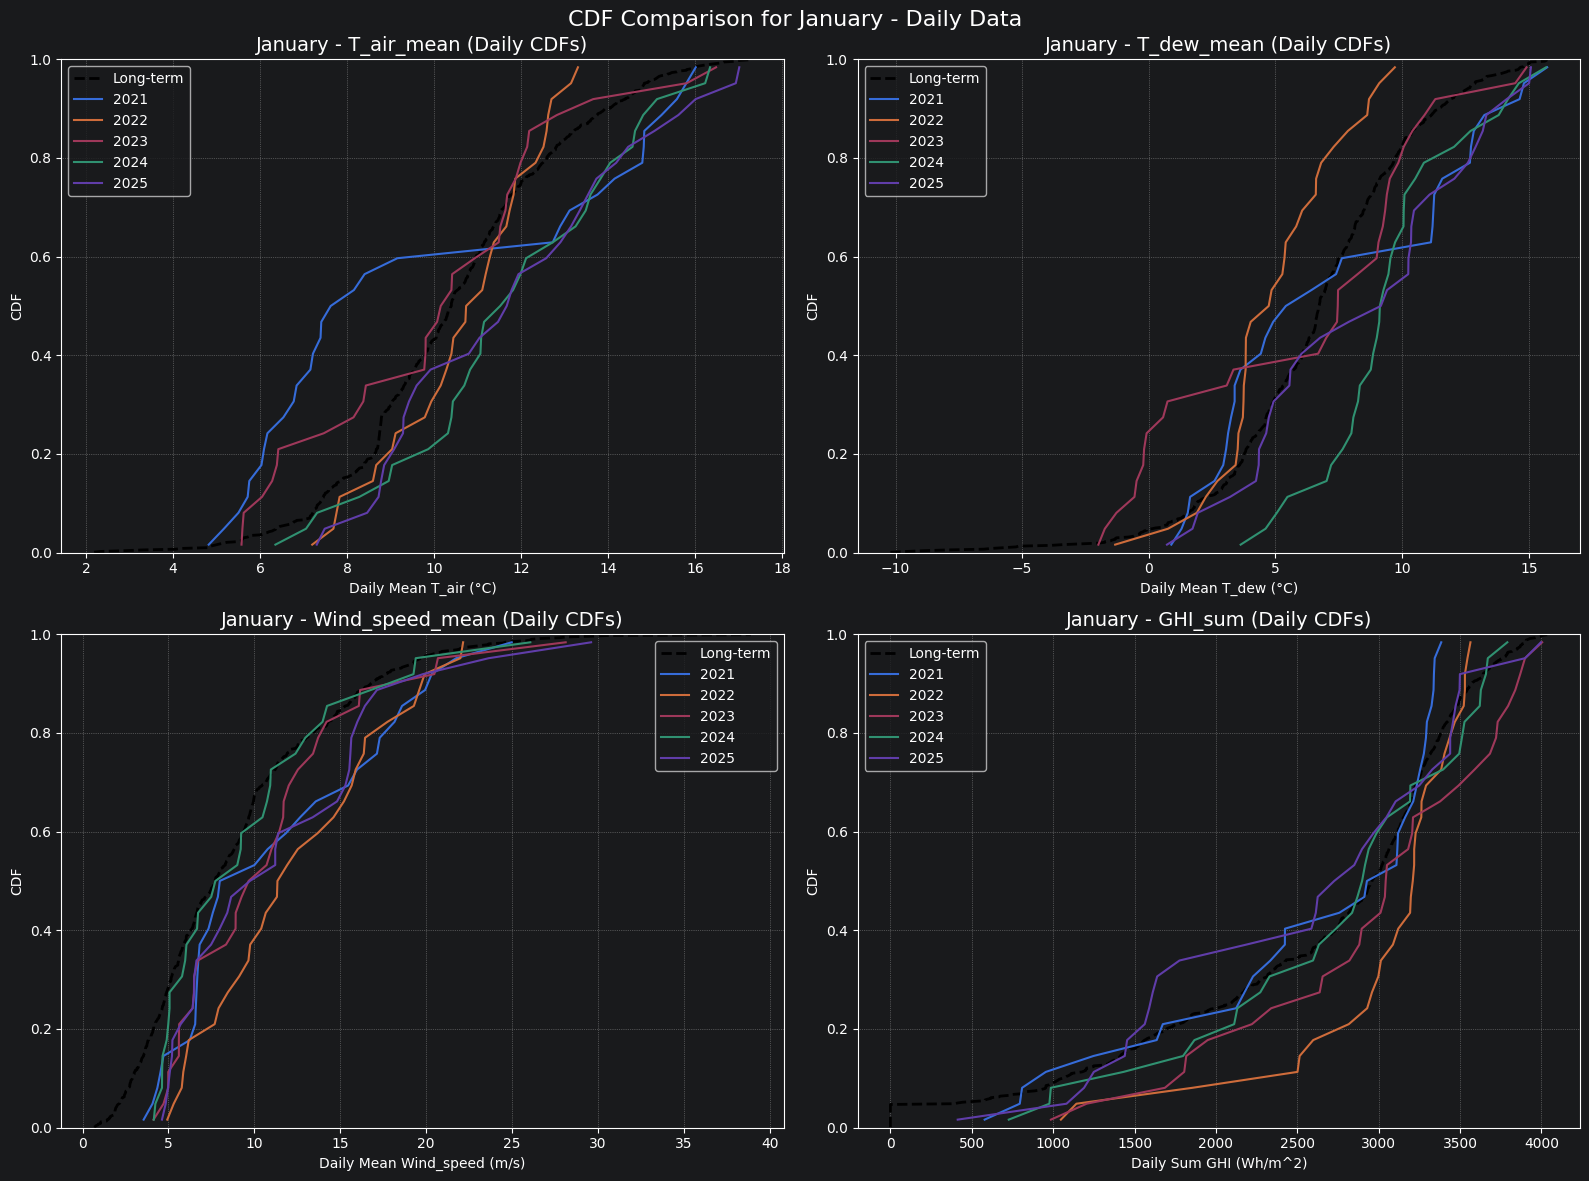

In [13]:
seville_step.plot_cdfs(month_to_plot=1)


Generating FS Statistic visualization for T_air_mean in January 2013...


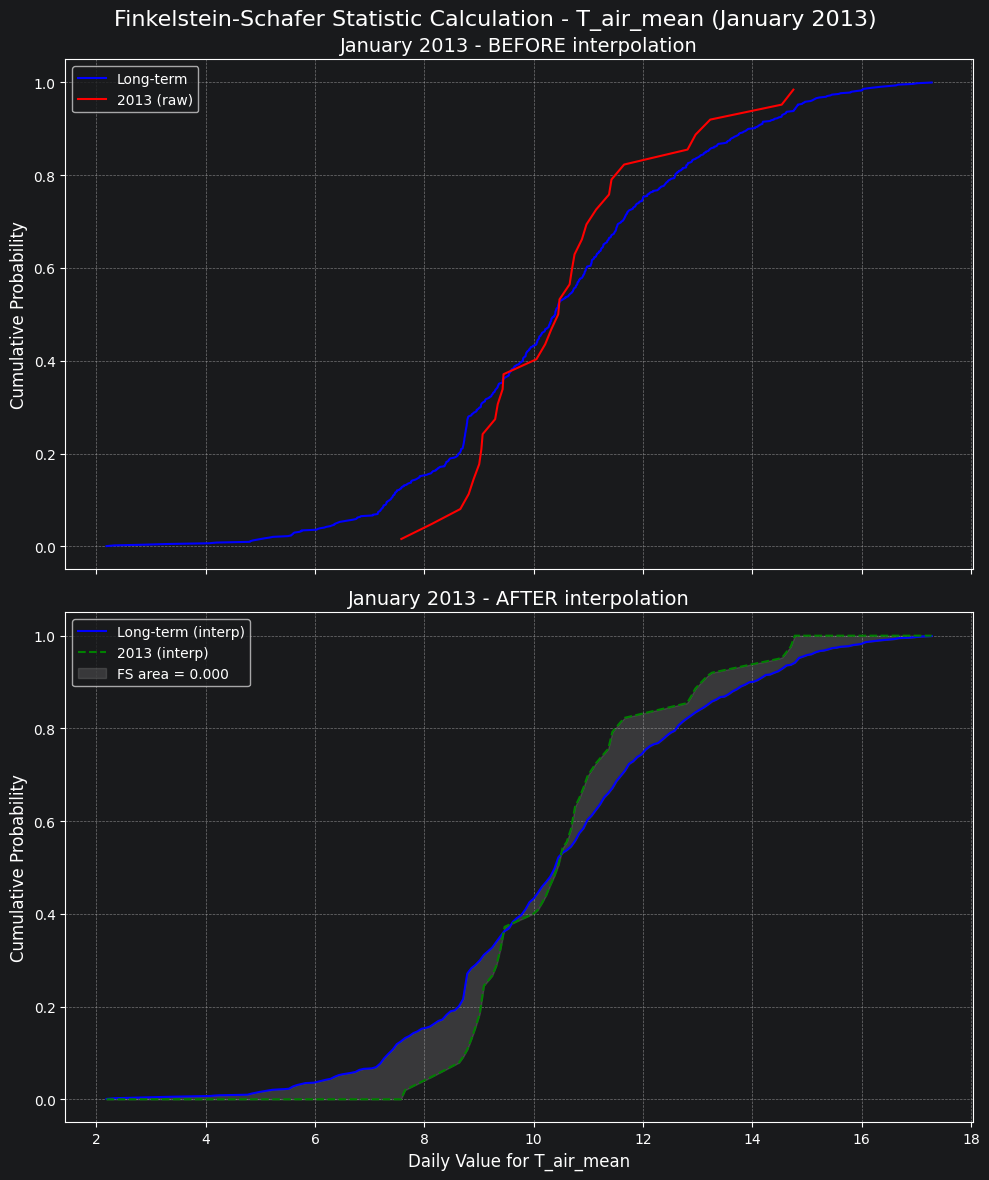

In [14]:
seville_step.plot_fs_details(var_to_plot='T_air_mean', month_to_plot=1, year_to_plot=2013)

#### Step 3 -- Proximity re-ranking (`sandia_step_3_proximity_ranking`)

Following Sawaqed et al. (Section 2.2.1 of the manuscript), the five FS-selected candidates are re-ordered by their closeness to the long-term monthly mean/median of temperature and GHI, normalised according to `normalization_method` (`'std'` here, the manuscript's default; alternatives are `'long_term_mean'`, `'range'`, `'weighted'` and `'no_normalization'`, see `AGENTS.md`). The result, `self.candidate_months`, is the definitive Top-5 list used by every subsequent step.

In [15]:
seville_step.sandia_step_3_proximity_ranking(normalization_method='std')

Step 3: Applying Proximity Ranking to re-order top 5 candidates (method='std')...
  Month 1: Re-ordered by Proximity -> [2013, 2018, 2006, 2025, 2021]
  Month 2: Re-ordered by Proximity -> [2009, 2011, 2015, 2016, 2013]
  Month 3: Re-ordered by Proximity -> [2017, 2011, 2021, 2010, 2009]
  Month 4: Re-ordered by Proximity -> [2013, 2008, 2015, 2016, 2010]
  Month 5: Re-ordered by Proximity -> [2007, 2023, 2017, 2005, 2012]
  Month 6: Re-ordered by Proximity -> [2021, 2022, 2015, 2007, 2014]
  Month 7: Re-ordered by Proximity -> [2013, 2017, 2008, 2011, 2014]
  Month 8: Re-ordered by Proximity -> [2005, 2021, 2011, 2013, 2017]
  Month 9: Re-ordered by Proximity -> [2023, 2021, 2013, 2012, 2019]
  Month 10: Re-ordered by Proximity -> [2013, 2008, 2018, 2016, 2023]
  Month 11: Re-ordered by Proximity -> [2025, 2005, 2016, 2011, 2023]
  Month 12: Re-ordered by Proximity -> [2007, 2016, 2005, 2012, 2023]


`get_candidate_stats` builds a compact per-candidate table (proximity rank, FS score, monthly mean temperature/GHI and their deviation from the long-term value) for a single calendar month -- note that `Is_Selected` is still `False` for every row at this point, since the final year-per-month selection only happens in Steps 4-5 below. `summarize_fs_results` prints the same Top-5 breakdown for every calendar month at once, now that `self.candidate_months` (the proximity-ordered list) is available.

In [16]:
seville_step.get_candidate_stats(month=1)

,Prox_Rank,Year,FS_Score,T_mean,T_diff_vs_LT,T_pctil,GHI_mean,GHI_diff_vs_LT,GHI_pctil,Is_Selected
0,1,2013,0.044720,10.520326,0.052223,57.142857,2679.303448,80.257943,42.857143,False
1,2,2018,0.038000,10.593548,0.125445,61.904762,2650.715110,51.669604,38.095238,False
2,3,2006,0.063676,9.890080,-0.578024,33.333333,2682.847654,83.802149,52.380952,False
3,4,2025,0.083321,11.725941,1.257837,80.952381,2512.590684,-86.454822,33.333333,False
4,5,2021,0.080672,9.731048,-0.737055,23.809524,2541.970277,-57.075228,33.333333,False


In [17]:
seville_step.summarize_fs_results()


--- Overall Summary of FS Results ---

Ranking Breakdown for the Top 5 Candidates of Each Month:
                Prox_Rank  Max_Error  Proximity_Score Proximity_Method  Den_T   Den_GHI  Weighted_Score  Raw_Err_T_Mean  Raw_Err_T_Med  Raw_Err_GHI_Mean  Raw_Err_GHI_Med  Norm_Err_T_Mean  Norm_Err_T_Med  Norm_Err_GHI_Mean  Norm_Err_GHI_Med  Total_W_FS
Month     Year                                                                                                                                                                                                                                             
January   2013          1     0.0802           0.0802              std 2.5368 1000.5381             NaN          0.0522         0.0539           80.2579          34.4900           0.0206          0.0212             0.0802            0.0345      0.0447
          2018          2     0.1537           0.1537              std 2.5368 1000.5381             NaN          0.1254         0.3899           5

#### Steps 4-5 -- Persistence filtering and final selection (`sandia_step_4_and_5_apply_persistence`)

To avoid selecting months that match the long-term distribution only on average while containing anomalous spells, run statistics are computed for consecutive days above/below the monthly 67th/33rd temperature percentile and below the GHI 33rd percentile. `persistence_method='sequential'` reproduces the three-pass deterministic exclusion procedure of Section 2.2.1 of the manuscript (worst run count, then longest run, tie-broken by proximity rank); the alternative `'score'` method instead applies a single weighted-penalty score. `thresholds=(0.33, 0.67)` and `min_run_length=1` are the method's defaults.

In [18]:
seville_step.sandia_step_4_and_5_apply_persistence(persistence_method='sequential')


Applying persistence criteria (Step 4) and Final Selection (Step 5)...


`validate_persistence_selection` prints the detailed per-month exclusion tables. `plot_persistence_runs` plots the daily temperature/GHI series of a given month for every one of its Top-5 candidate years, with the persistence runs highlighted, directly visualising why a given year was excluded or retained.

In [19]:
seville_step.validate_persistence_selection()


--- Validation for Step 3: Persistence Decisions (Sequential Exclusion) ---

Persistence Table for January:
 Prox_Rank  Year  FS_Score  NumRuns  Max_run                               Decision
         1  2013     0.045       15        5    Excluded Pass 1 (Rule 1c: Max Runs)
         2  2018     0.038       13        5                     SELECTED TMY MONTH
         3  2006     0.064       11        7                                       
         4  2025     0.083       12       11                                       
         5  2021     0.081        8       19 Excluded Pass 2 (Rule 2a: Longest Run)
--> Selected Year: 2018

Persistence Table for February:
 Prox_Rank  Year  FS_Score  NumRuns  Max_run                               Decision
         1  2009     0.070        9        8                     SELECTED TMY MONTH
         2  2011     0.085        8        9                                       
         3  2015     0.079       12        6                                  


--- Visualizing Persistence Runs for T_air and GHI in January ---


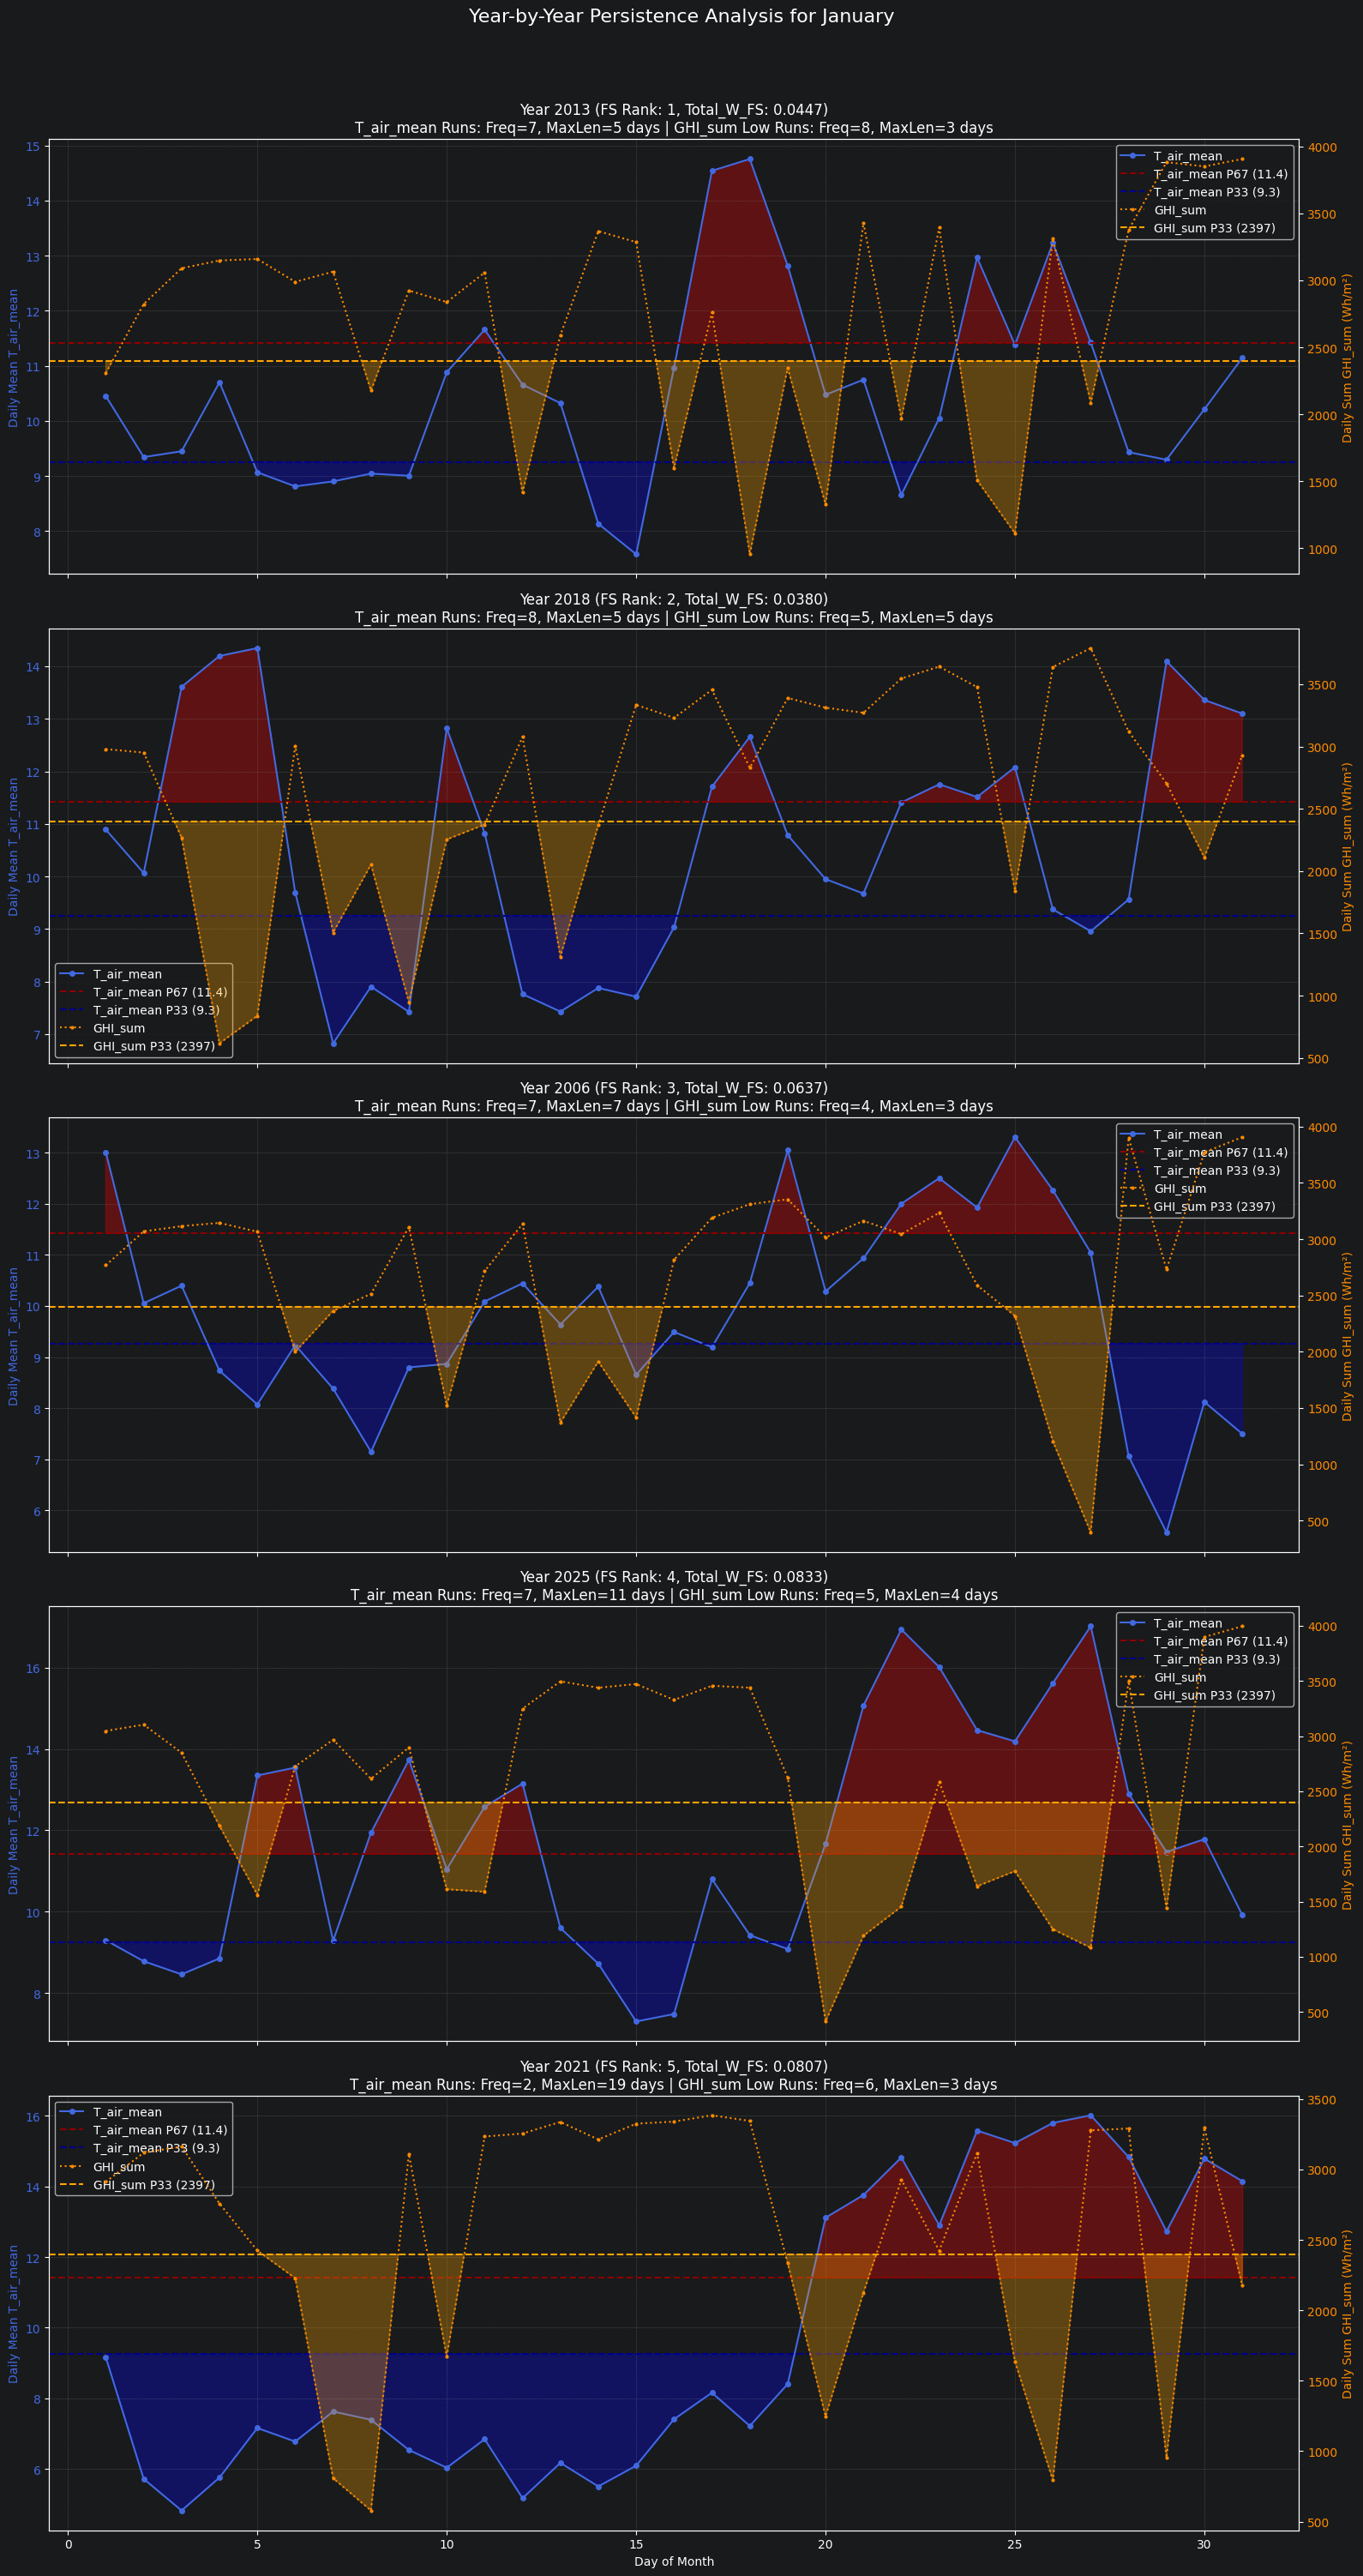

In [20]:
seville_step.plot_persistence_runs(month=1, years=seville_step.candidate_months[1])

#### Step 6 -- Raw TMY assembly (`sandia_step_6_assemble_tmy`)

The twelve selected typical months -- drawn, in general, from different years -- are extracted at hourly resolution, re-indexed onto a common synthetic year (year 2000), stripped of any 29 February, and concatenated into a raw, unsmoothed 8760-hour TMY (`self.tmy_raw`).

In [21]:
seville_step.sandia_step_6_assemble_tmy()


Step 6: Creating raw (un-smoothed) TMY...


`plot_junctions` plots the raw (pre-smoothing) hourly data around a specified list of `(variable, month)` month-to-month junctions, letting us inspect the discontinuities that Step 7 is designed to remove. We look at the January-to-February junction for dry-bulb temperature.


--- Visualizing Raw Month Junctions (Pre-Smoothing) ---


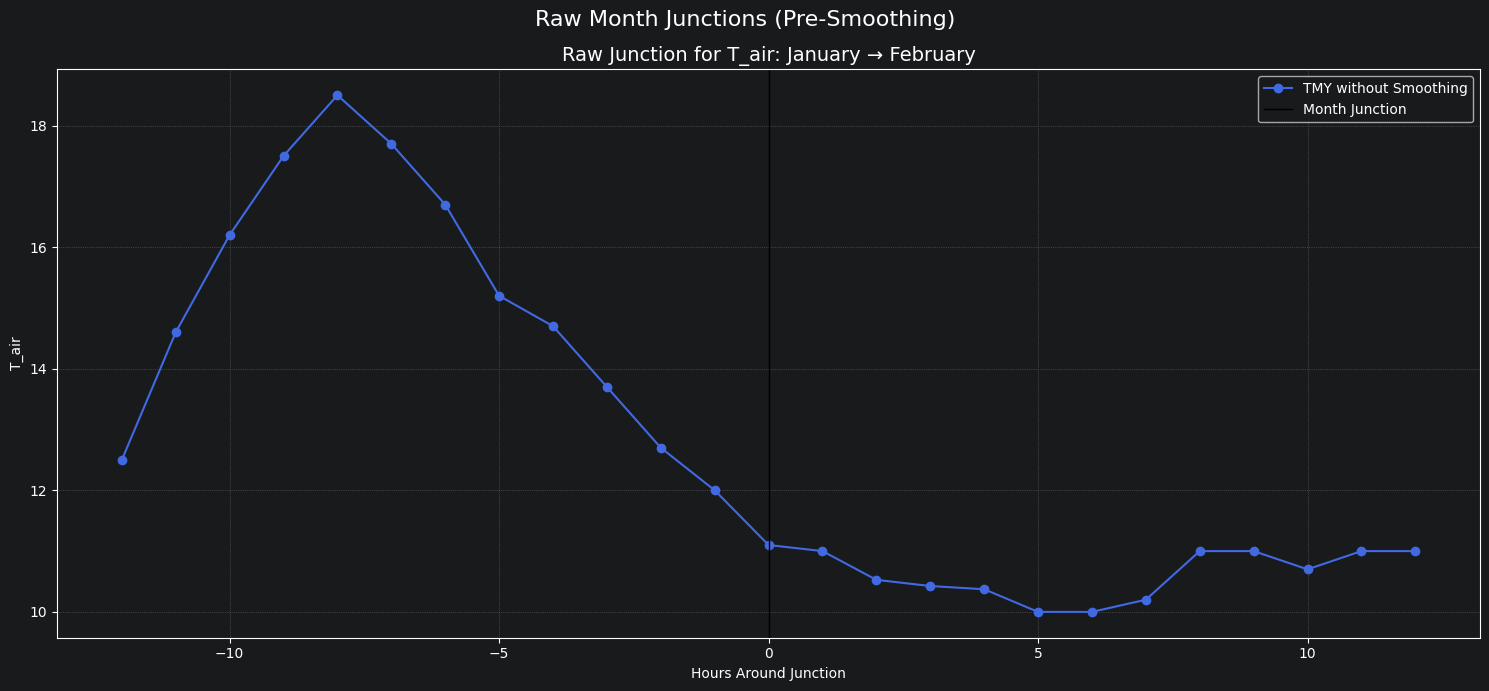

In [22]:
seville_step.plot_junctions(junctions_to_plot=[('T_air', 1)])

#### Step 7 -- Junction smoothing (`sandia_step_7_smooth_junctions`)

For each of the eleven month-to-month junctions, a smoothing spline is fitted to the two complete adjacent source months and evaluated over a window of `hours` (default 6) hours either side of the transition; the raw values inside that window are replaced by the smoothed ones for every variable **except** GHI and DNI, which are left untouched so that the solar geometry of the source data is never distorted. How much smoothing is applied is governed by `s_factor`, which defaults to `'auto'`: for each variable the spline's `s` is computed as `auto_s_strength * n * var(y)` (with `auto_s_strength = 0.02`), i.e. proportional to the variance of the two months being fitted, so that temperature, dew point and wind speed all receive a comparable *relative* amount of smoothing regardless of their units. This is also the step that -- since `save_validation_dfs=True` -- automatically calls `generate_full_summary()` internally.

```{note}
`s_factor` also accepts a plain number, handed verbatim to `scipy.interpolate.UnivariateSpline`. In particular `s_factor=0.0` means *exact interpolation*: the spline passes through every fitted point, the smoothed values come out numerically identical to the raw ones, and the TMY therefore remains strictly made of measured hours (Step 7 still runs, but it is a no-op by construction -- this was the package default before the switch to `auto`). `s_factor=None` falls back to SciPy's own criterion (`s = n`), which is unit-dependent and strong enough to flatten low-variance variables such as wind speed. Per-junction overrides can be passed through `smoothing_config`, e.g. `{1: {'hours_before': 12, 'hours_after': 3}, 7: {'s_factor': 0.0}}`.
```

In [23]:
seville_step.sandia_step_7_smooth_junctions()

Applying sophisticated smoothing at month junctions...
  - Junction 1->2: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 2->3: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 3->4: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 4->5: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 5->6: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 6->7: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 7->8: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 8->9: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 9->10: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 10->11: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Junction 11->12: hours_before=6, hours_after=6, s_factor='auto' (strength=0.02)
  - Fixed 2 negative values in 'Wind_s

`plot_smoothing_comparison` overlays the raw and the smoothed hourly series around the same junction inspected above, so the effect of Step 7 is directly visible, and reports the parameters actually used in the figure title (`h_before`, `h_after`, and the numeric `s` that `'auto'` resolved to for this particular variable and junction). `validate_step_4_final_tmy` prints the final TMY composition table together with `.describe()` of `self.tmy_final`.


--- Comparing Smoothing Effect ---


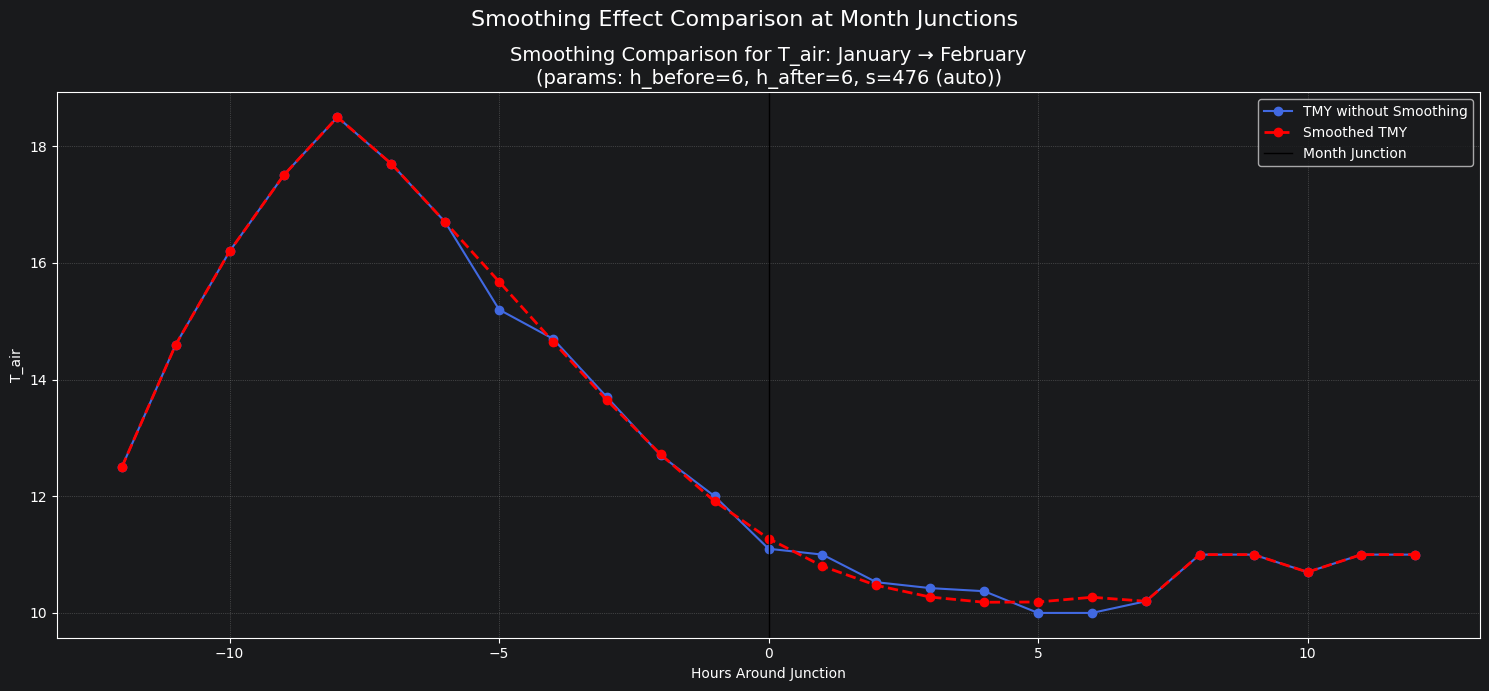

In [24]:
seville_step.plot_smoothing_comparison(junctions_to_plot=[('T_air', 1)])

In [25]:
seville_step.validate_step_4_final_tmy()


--- Validation for Step 4: Final TMY ---

TMY Composition Table:
           Month_Num  Source_Year  Prox_Rank  Max_Error  Proximity_Score Proximity_Method     Den_T      Den_GHI  Weighted_Score  Raw_Err_T_Mean  Raw_Err_T_Med  Raw_Err_GHI_Mean  Raw_Err_GHI_Med  Norm_Err_T_Mean  Norm_Err_T_Med  Norm_Err_GHI_Mean  Norm_Err_GHI_Med  Total_W_FS
Month                                                                                                                                                                                                                                                                               
January            1         2018          2   0.153693         0.153693              std  2.536843  1000.538138             NaN        0.125445       0.389894         51.669604           7.4843         0.049449        0.153693           0.051642          0.007480    0.038000
February           2         2009          1   0.245940         0.245940              std  2.524484  13

Step 7 already called `generate_full_summary()` internally, consolidating one row per month with the FS score/rank, proximity rank, persistence decision, and the selected year's temperature/GHI deviation from the long-term mean. We display the resulting `self.validation_full_summary` table.

In [26]:
seville_step.validation_full_summary

,Month,Month_Num,Source_Year,FS_Total_W_FS,FS_Rank_Overall,FS_Num_Years,Prox_Rank,Persist_NumRuns,Persist_MaxRun,Persist_Decision,LT_T_mean,Sel_T_mean,T_diff,LT_GHI_mean,Sel_GHI_mean,GHI_diff
0,January,1,2018,0.038000,1,21,2,13,5,SELECTED TMY MONTH,10.47,10.59,0.13,2599.05,2650.72,51.67
1,February,2,2009,0.070390,1,21,1,9,8,SELECTED TMY MONTH,11.87,12.21,0.34,3411.34,3641.70,230.36
2,March,3,2011,0.052006,1,21,2,9,7,SELECTED TMY MONTH,14.31,14.11,-0.20,4561.48,4466.73,-94.75
3,April,4,2008,0.058805,2,21,2,7,6,SELECTED TMY MONTH,17.19,18.01,0.82,5797.47,6030.03,232.56
4,May,5,2007,0.069847,4,21,1,11,6,SELECTED TMY MONTH,20.96,20.86,-0.10,6884.36,7011.24,126.88
5,June,6,2021,0.077224,4,21,1,7,7,SELECTED TMY MONTH,24.70,24.43,-0.27,7467.65,7922.03,454.38
6,July,7,2013,0.055516,2,21,1,10,7,SELECTED TMY MONTH,27.20,27.40,0.20,7732.57,8025.17,292.60
7,August,8,2021,0.068468,4,21,2,11,6,SELECTED TMY MONTH,27.45,28.09,0.64,6836.35,7094.43,258.08
8,September,9,2021,0.059303,4,21,2,9,4,SELECTED TMY MONTH,23.91,24.47,0.56,5339.27,5552.96,213.69
9,October,10,2013,0.050059,2,21,1,10,8,SELECTED TMY MONTH,20.31,20.60,0.29,3800.07,4019.85,219.78


#### Post-generation diagnostics and plots

With the TMY fully generated, `TMYGenerator` exposes a further set of analysis and plotting methods operating on the final result.

`analyze_selection` flags any month whose selected year deviates from the long-term mean temperature and/or GHI beyond a threshold (`temp_diff_threshold=1.0` degrees Celsius by default; `ghi_diff_threshold=None` disables the GHI check unless set). `verbose=True` additionally prints a formatted table.

In [27]:
selection_analysis = seville_step.analyze_selection(temp_diff_threshold=1.0)


  TMY SELECTION ANALYSIS  (T=|1.0|﷿﷿C)
Month          Year  FS_Rank   T_LT(﷿﷿C)  T_Sel(﷿﷿C)    T_Diff       GHI_LT      GHI_Sel   GHI_Diff  Flag
----------------------------------------------------------------------------------------------------
January        2018       #2      10.47      10.59     +0.13       2599.1       2650.7      +51.7  
February       2009       #1      11.87      12.21     +0.34       3411.3       3641.7     +230.4  
March          2011       #2      14.31      14.11     -0.20       4561.5       4466.7      -94.8  
April          2008       #2      17.19      18.01     +0.82       5797.5       6030.0     +232.6  
May            2007       #1      20.96      20.86     -0.10       6884.4       7011.2     +126.9  
June           2021       #1      24.70      24.43     -0.27       7467.6       7922.0     +454.4  
July           2013       #1      27.20      27.40     +0.20       7732.6       8025.2     +292.6  
August         2021       #2      27.45      28.09   

`plot_monthly_trend` plots the year-by-year evolution of a variable's monthly mean, starring the TMY-selected year and drawing its linear trend line (`show_candidates=True` additionally overlays the other Top-5 candidates). `plot_monthly_series` plots the full daily series of every available year for the requested month(s), highlighting the selected year.

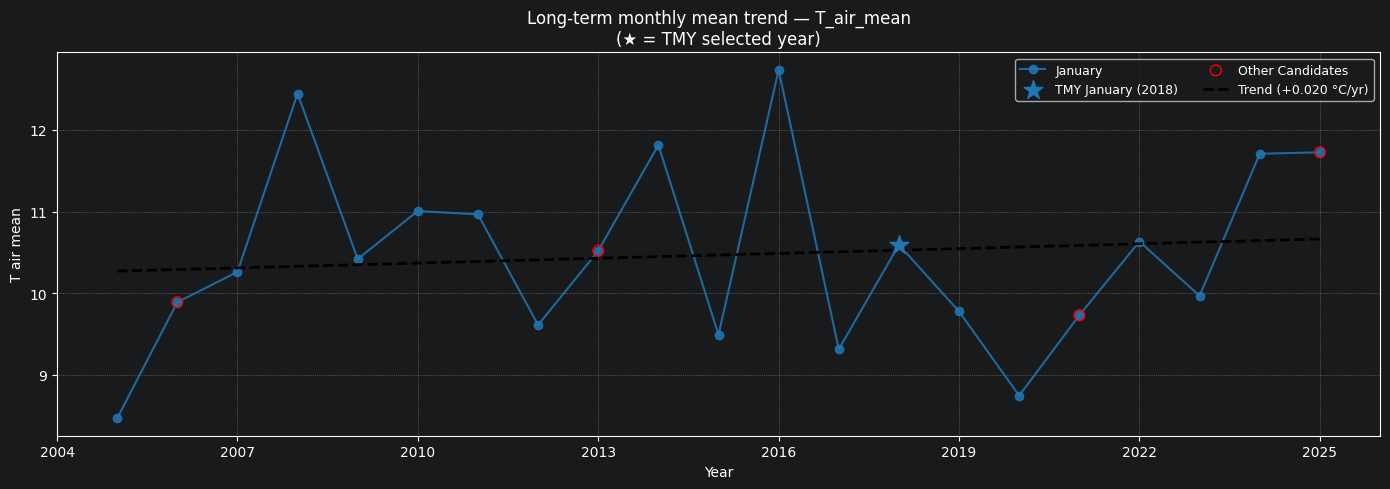

In [28]:
fig_trend_jan = seville_step.plot_monthly_trend(variable='T_air_mean', months=[1], show_candidates=True)

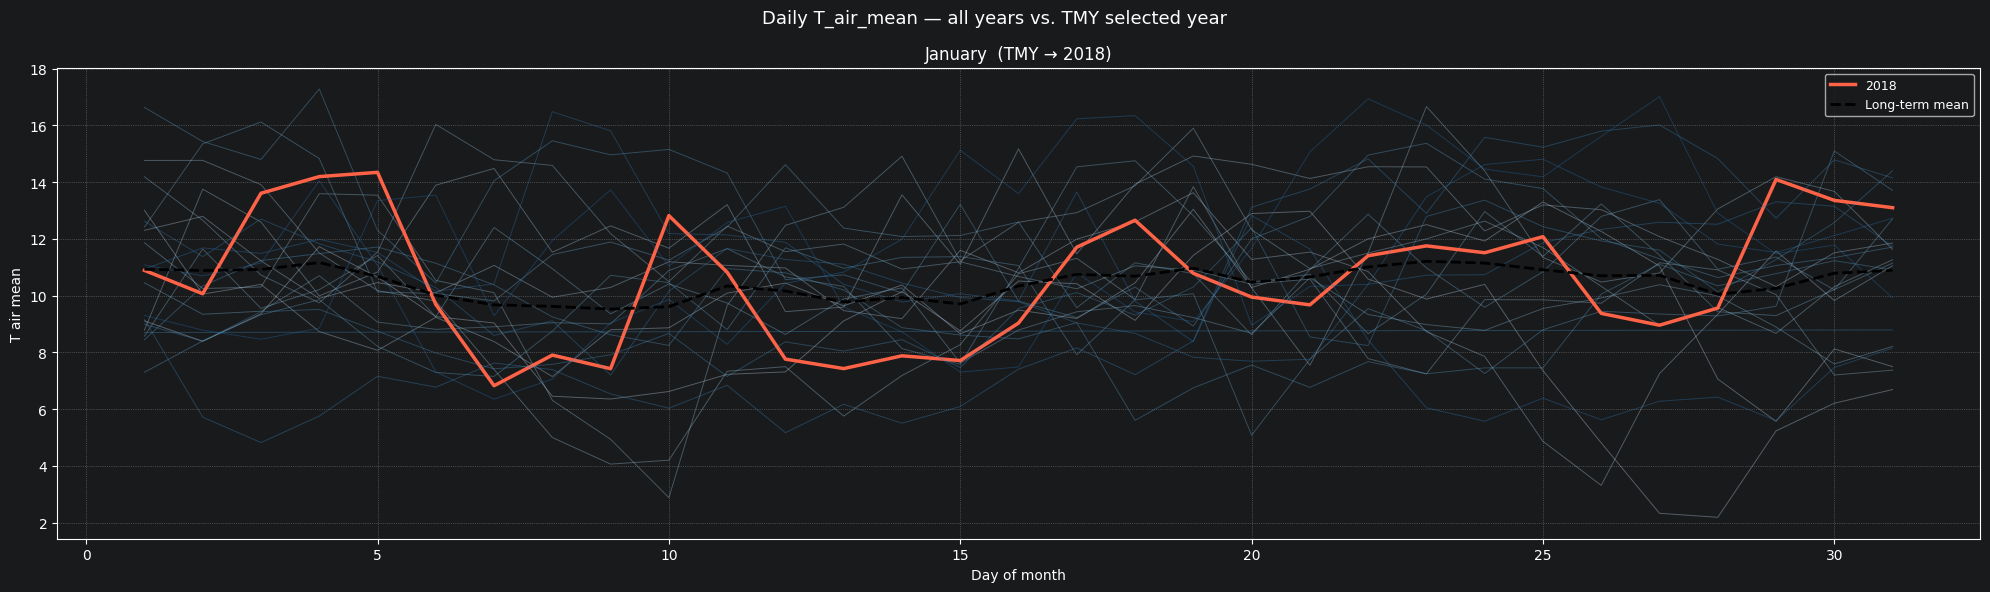

In [29]:
fig_series_jan = seville_step.plot_monthly_series(variable='T_air_mean', months=[1])

Three further plots summarise the final TMY against the long-term climate as a whole: `plot_annual_cdfs` (annual CDF of the TMY vs. long-term, for temperature/dew point/wind/GHI), `plot_monthly_means` (monthly mean of the TMY vs. long-term for the same four variables) and `plot_monthly_cdfs` (a 12-month grid of CDF comparisons per variable).


--- Plotting Annual CDF Comparison: Final TMY vs. Long-term ---


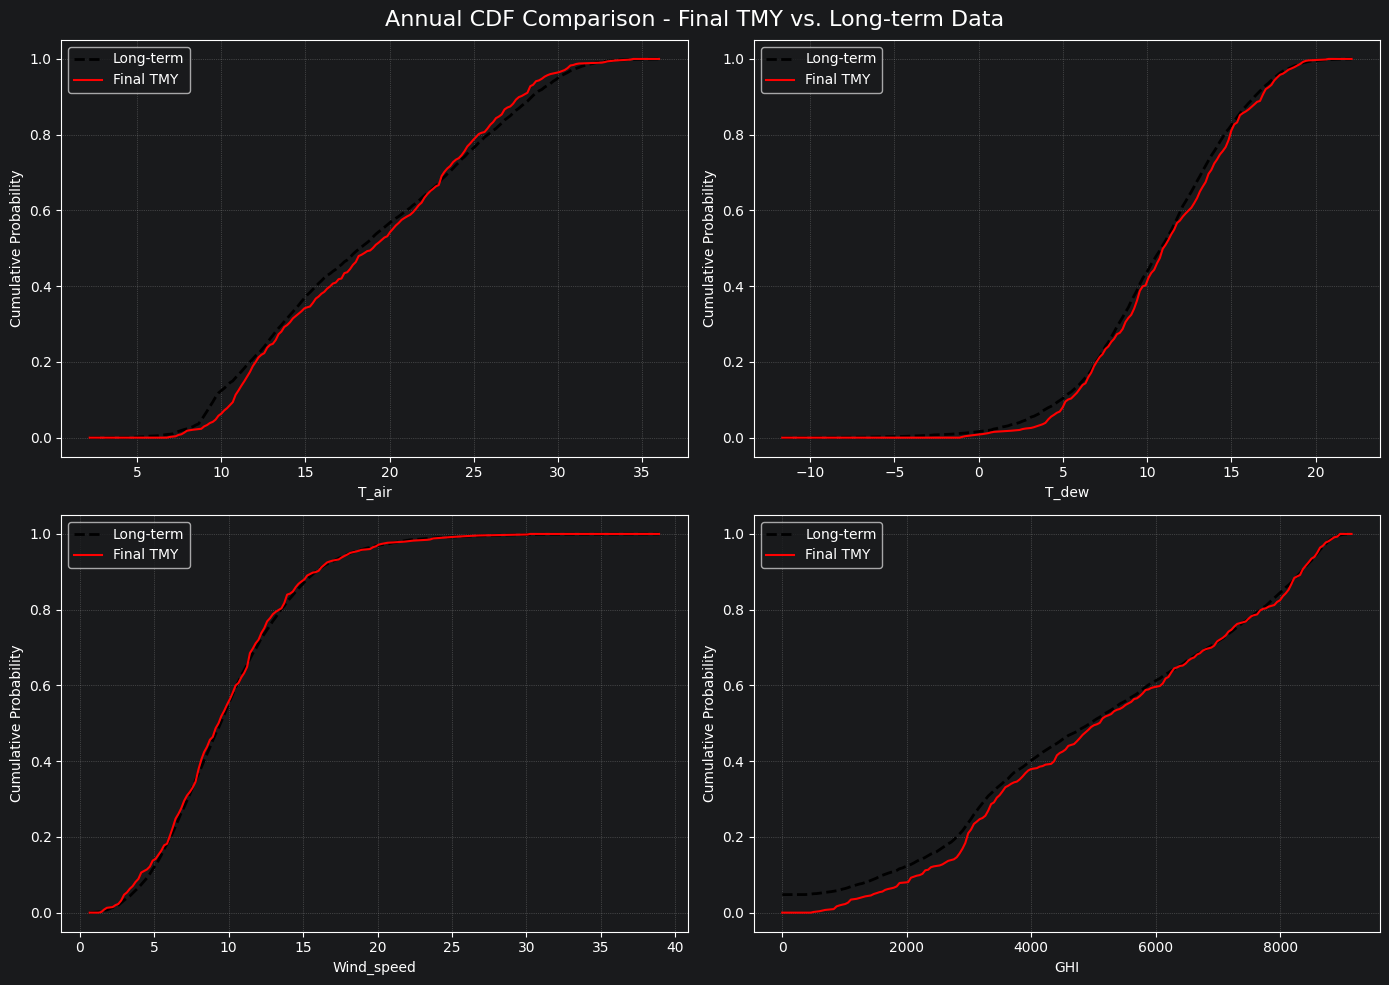

In [30]:
seville_step.plot_annual_cdfs()


--- Plotting Monthly Mean Comparison: Final TMY vs. Long-term ---


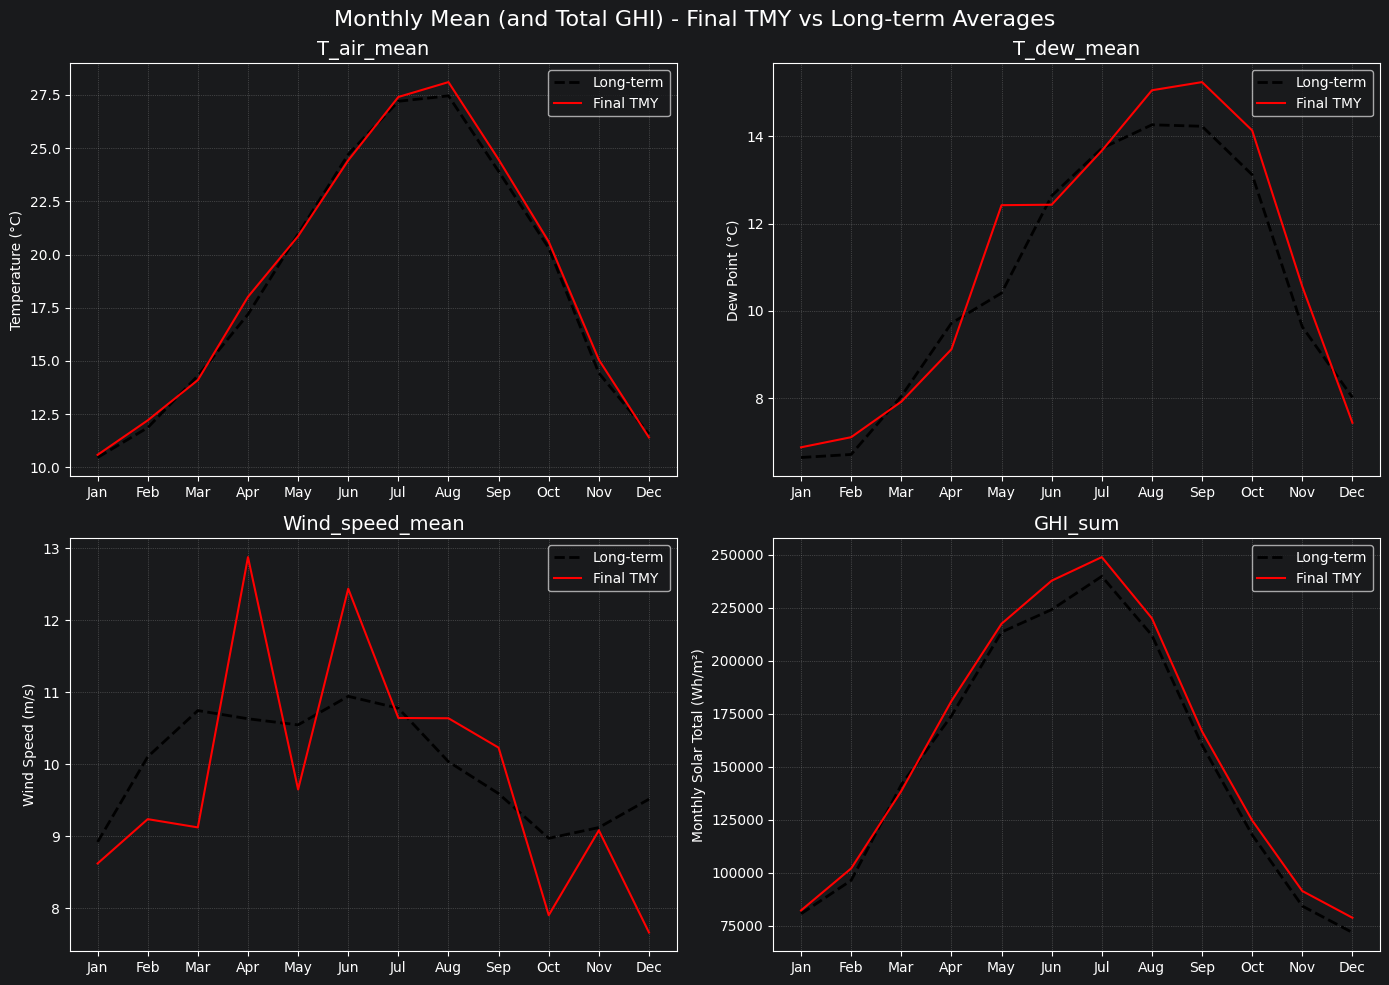

In [31]:
seville_step.plot_monthly_means()


--- Plotting Monthly CDF Comparison: Final TMY vs. Long-term ---


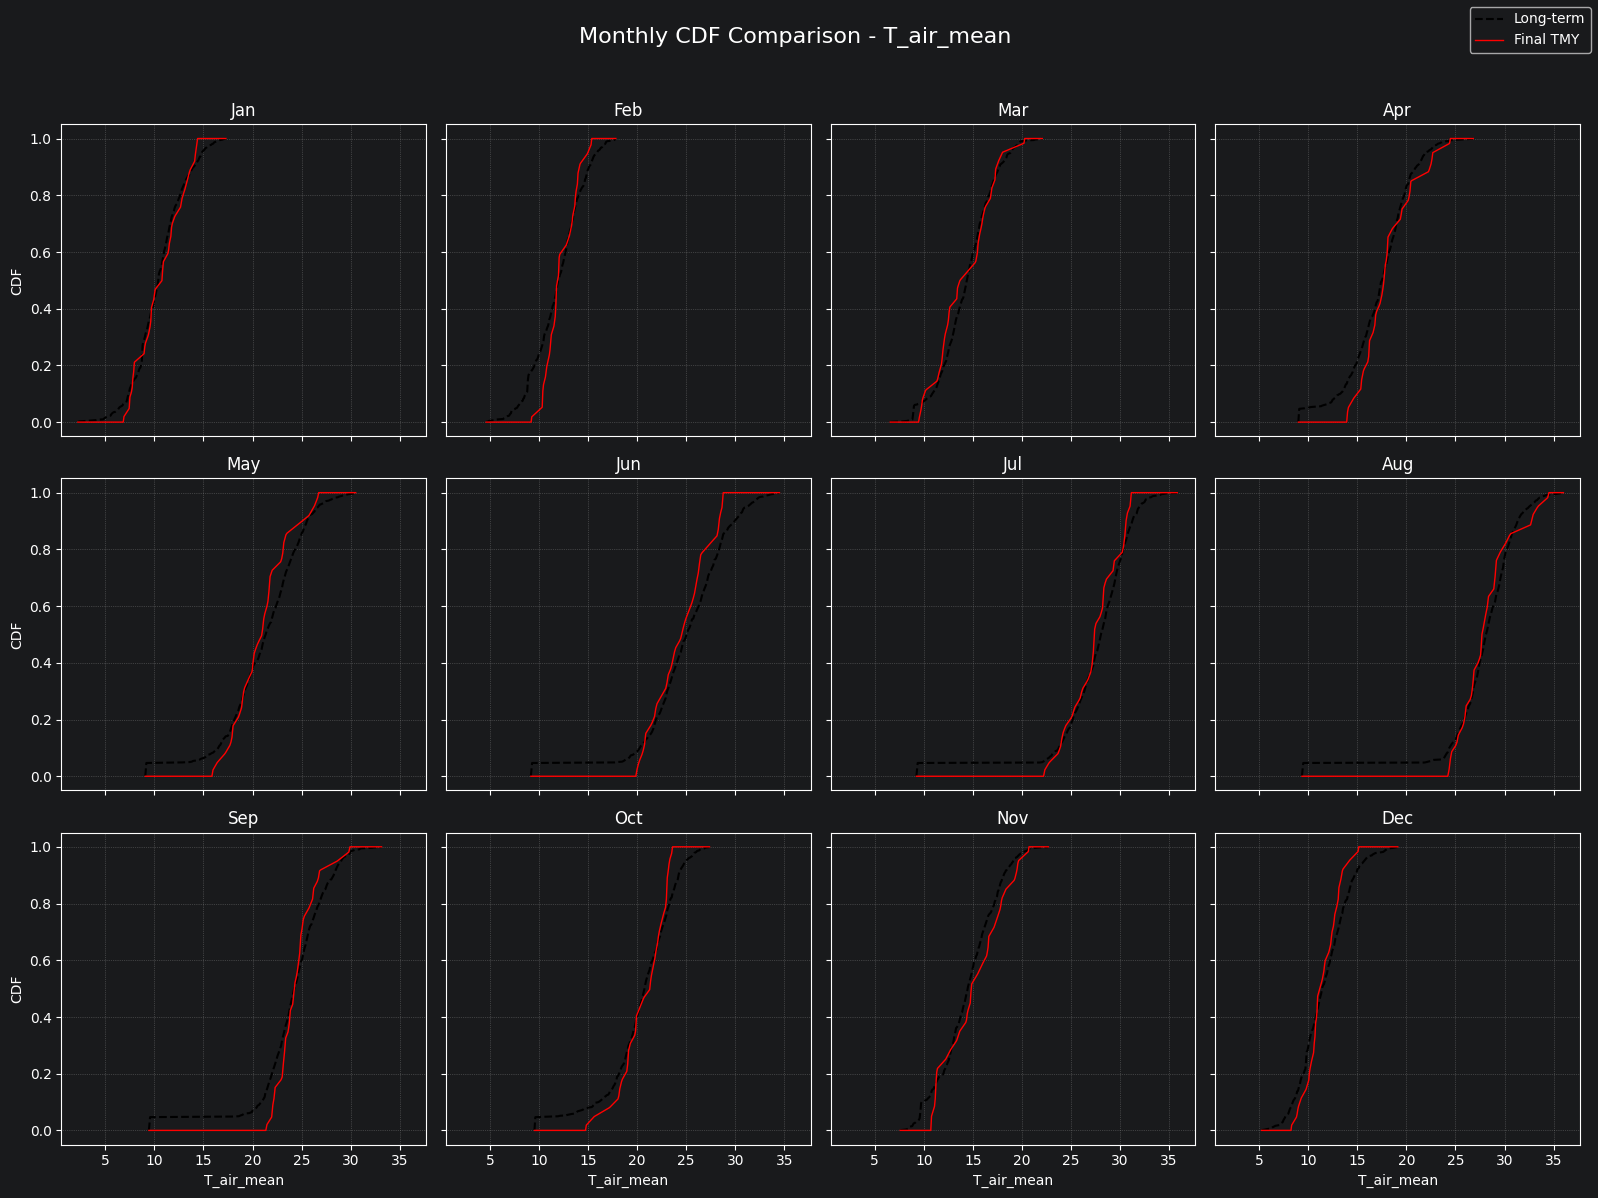

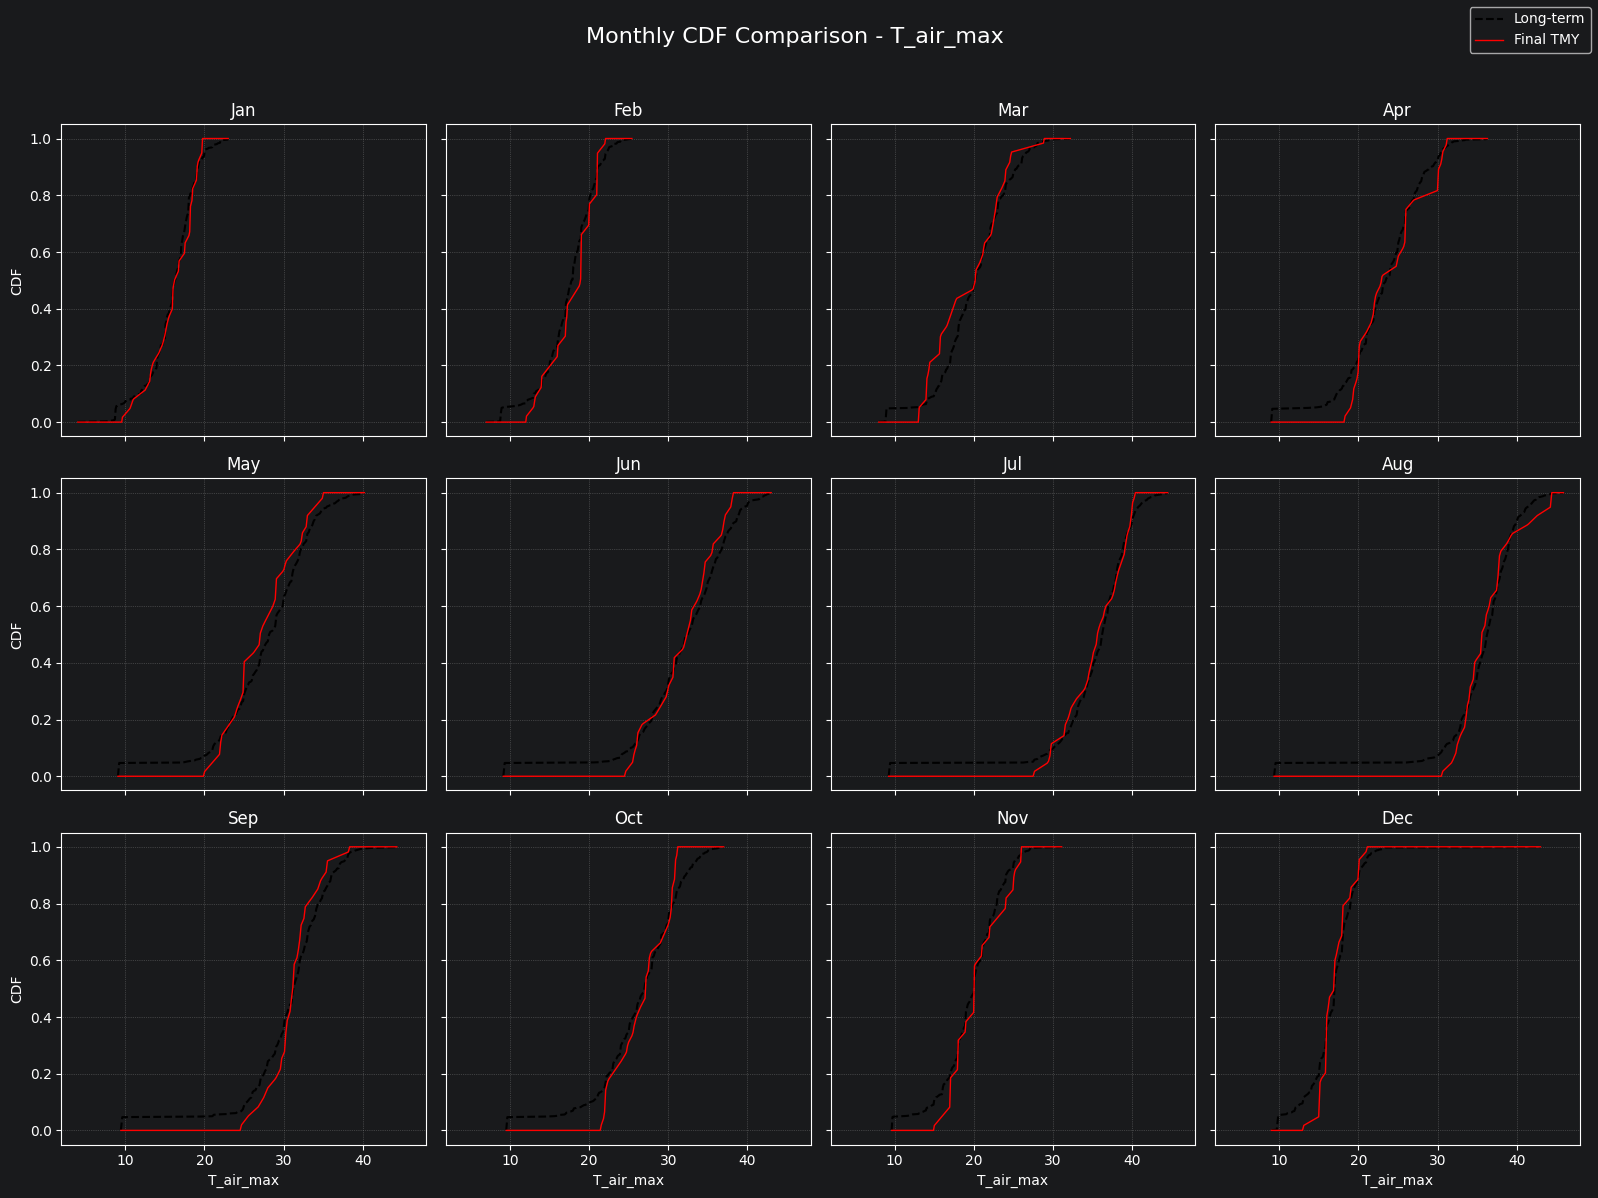

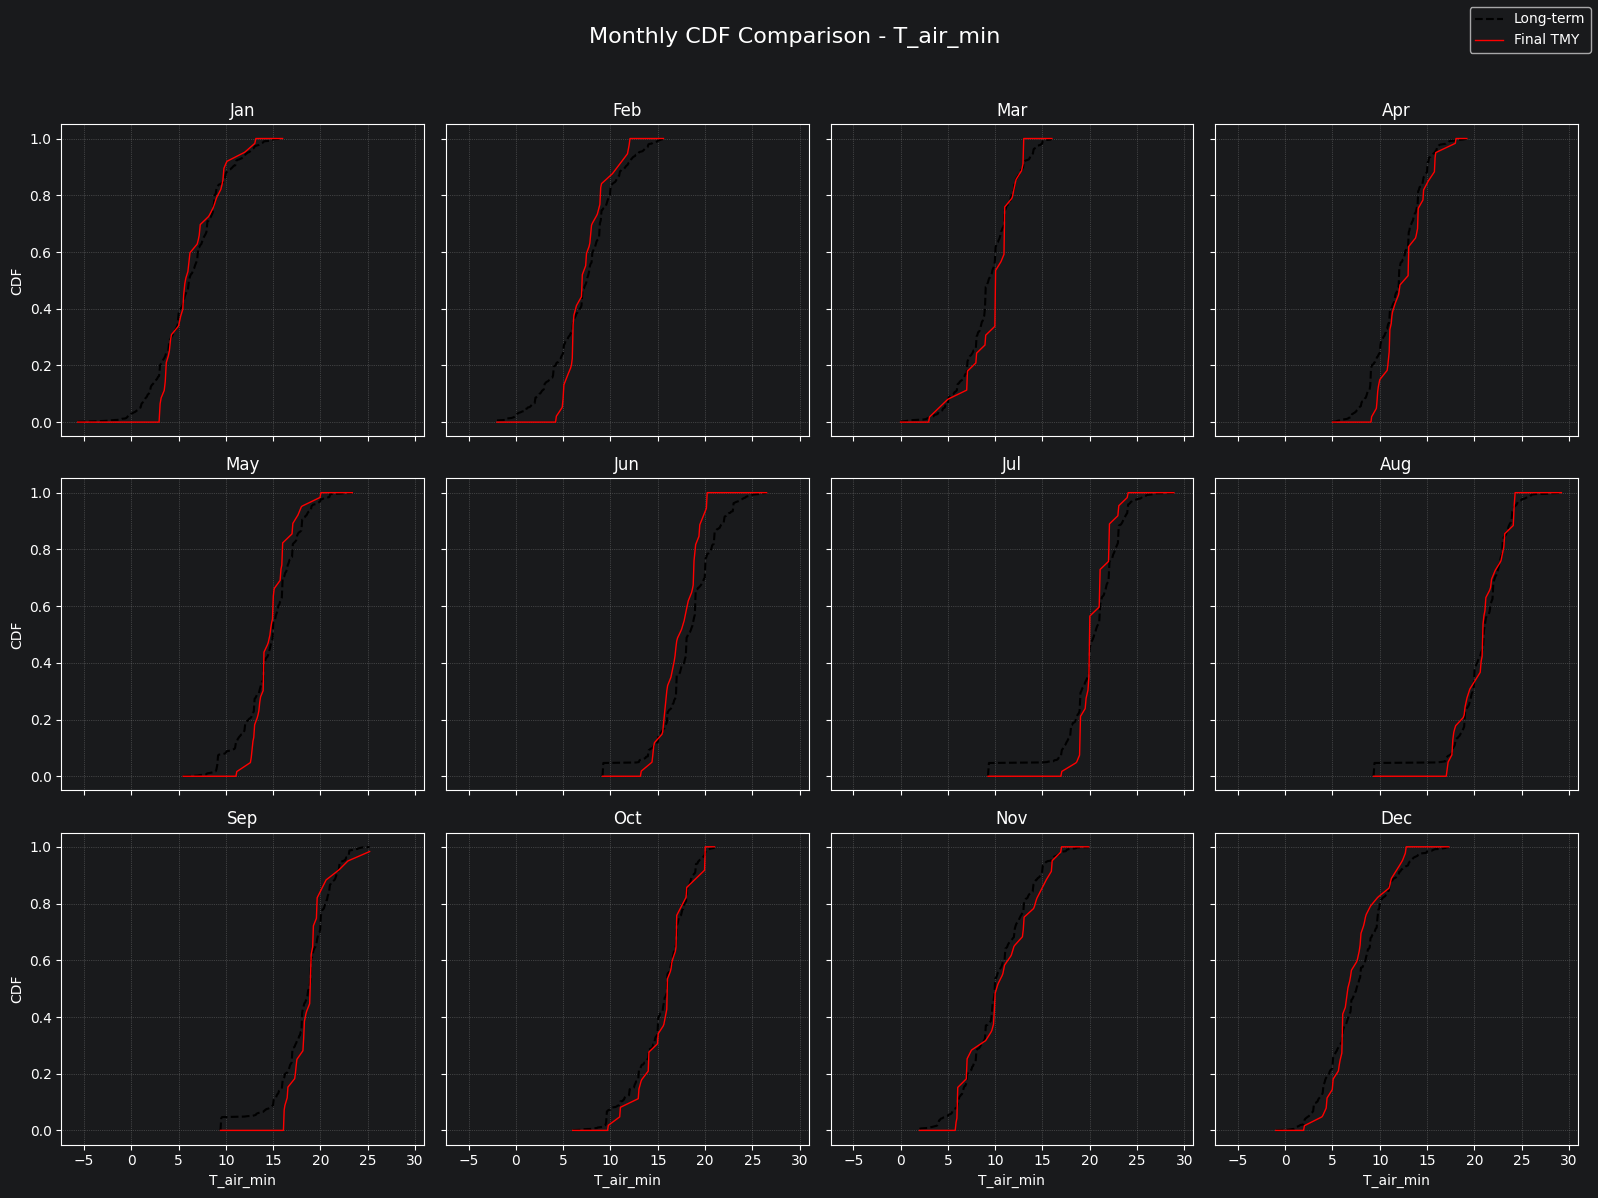

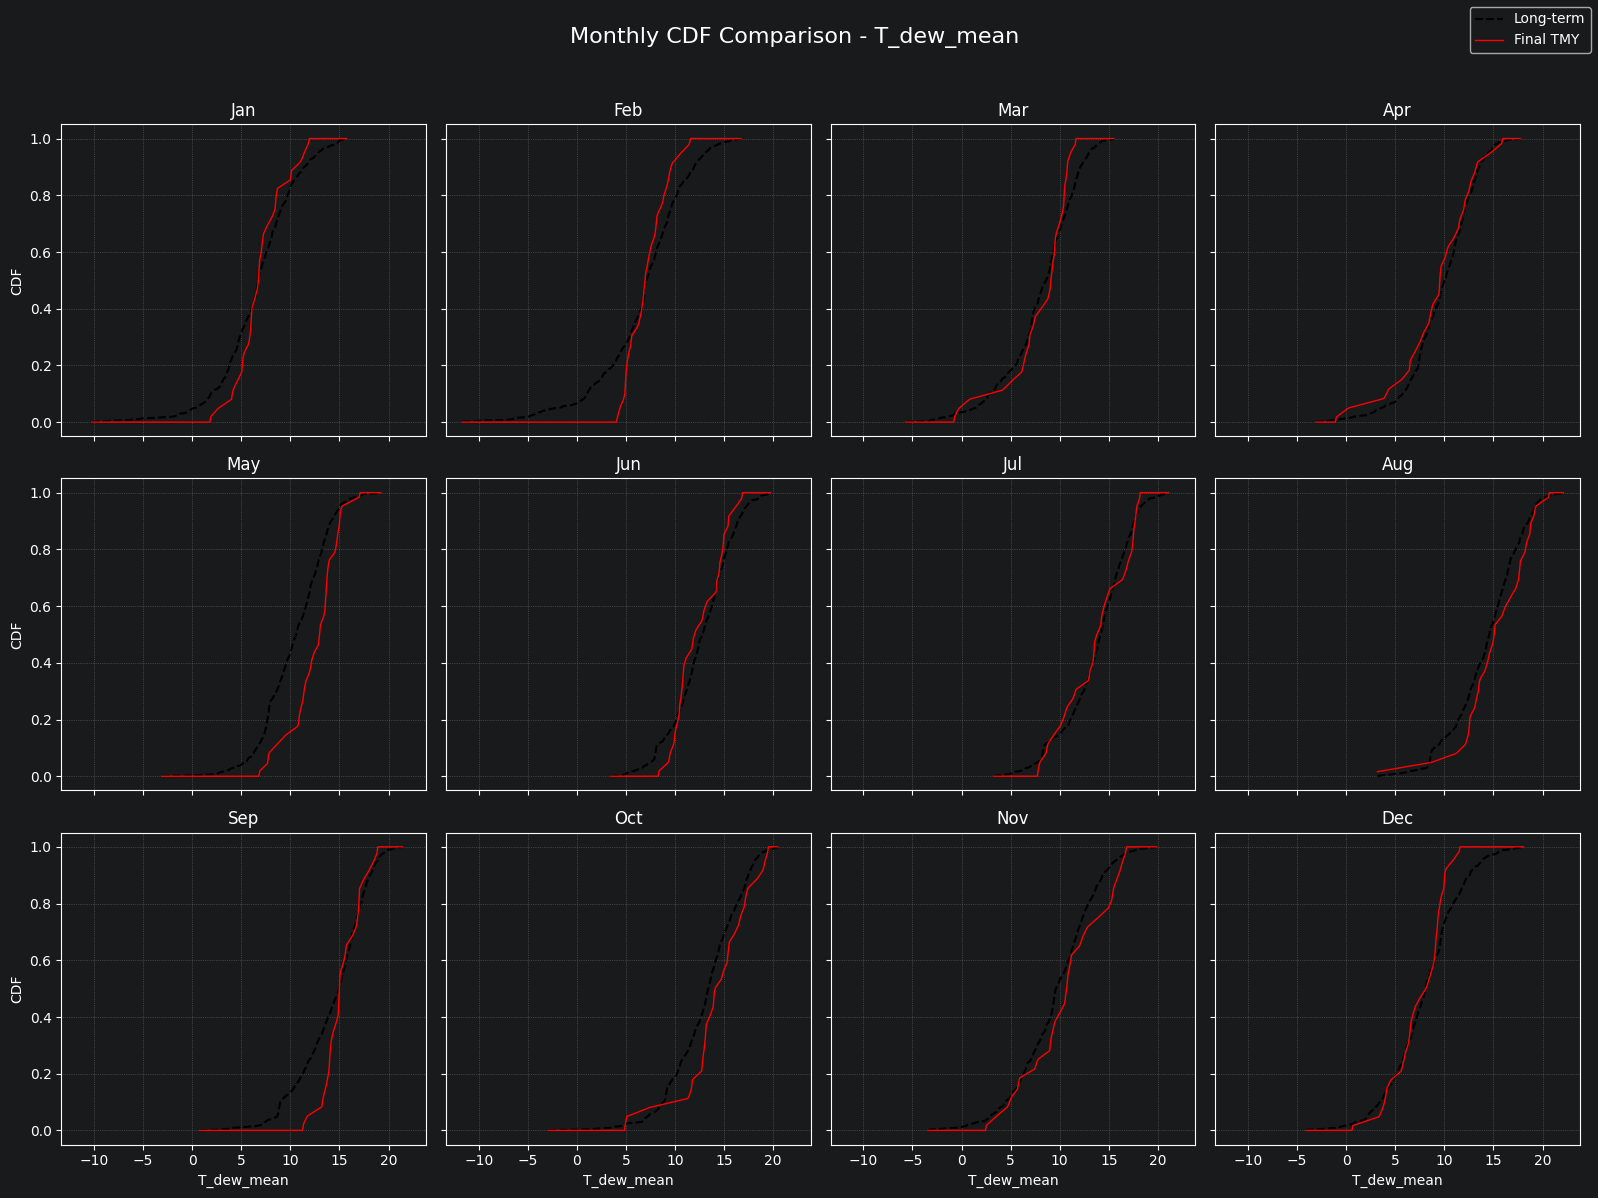

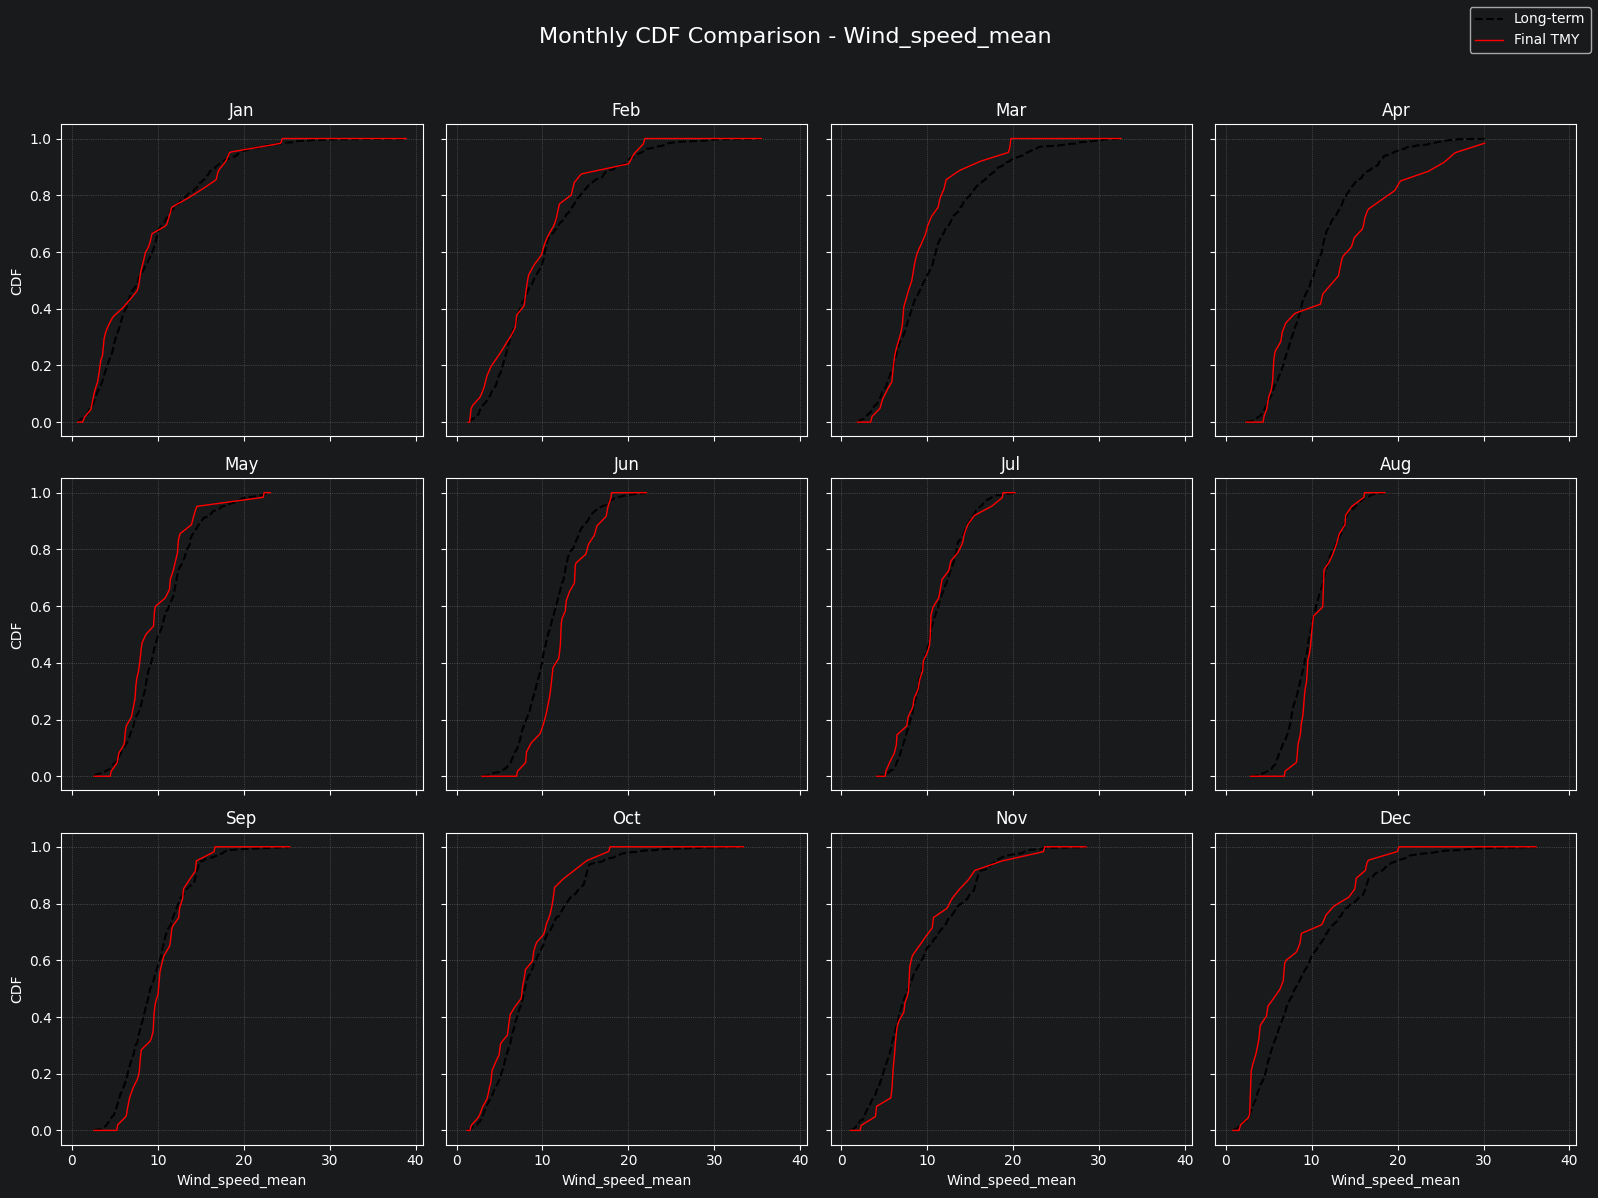

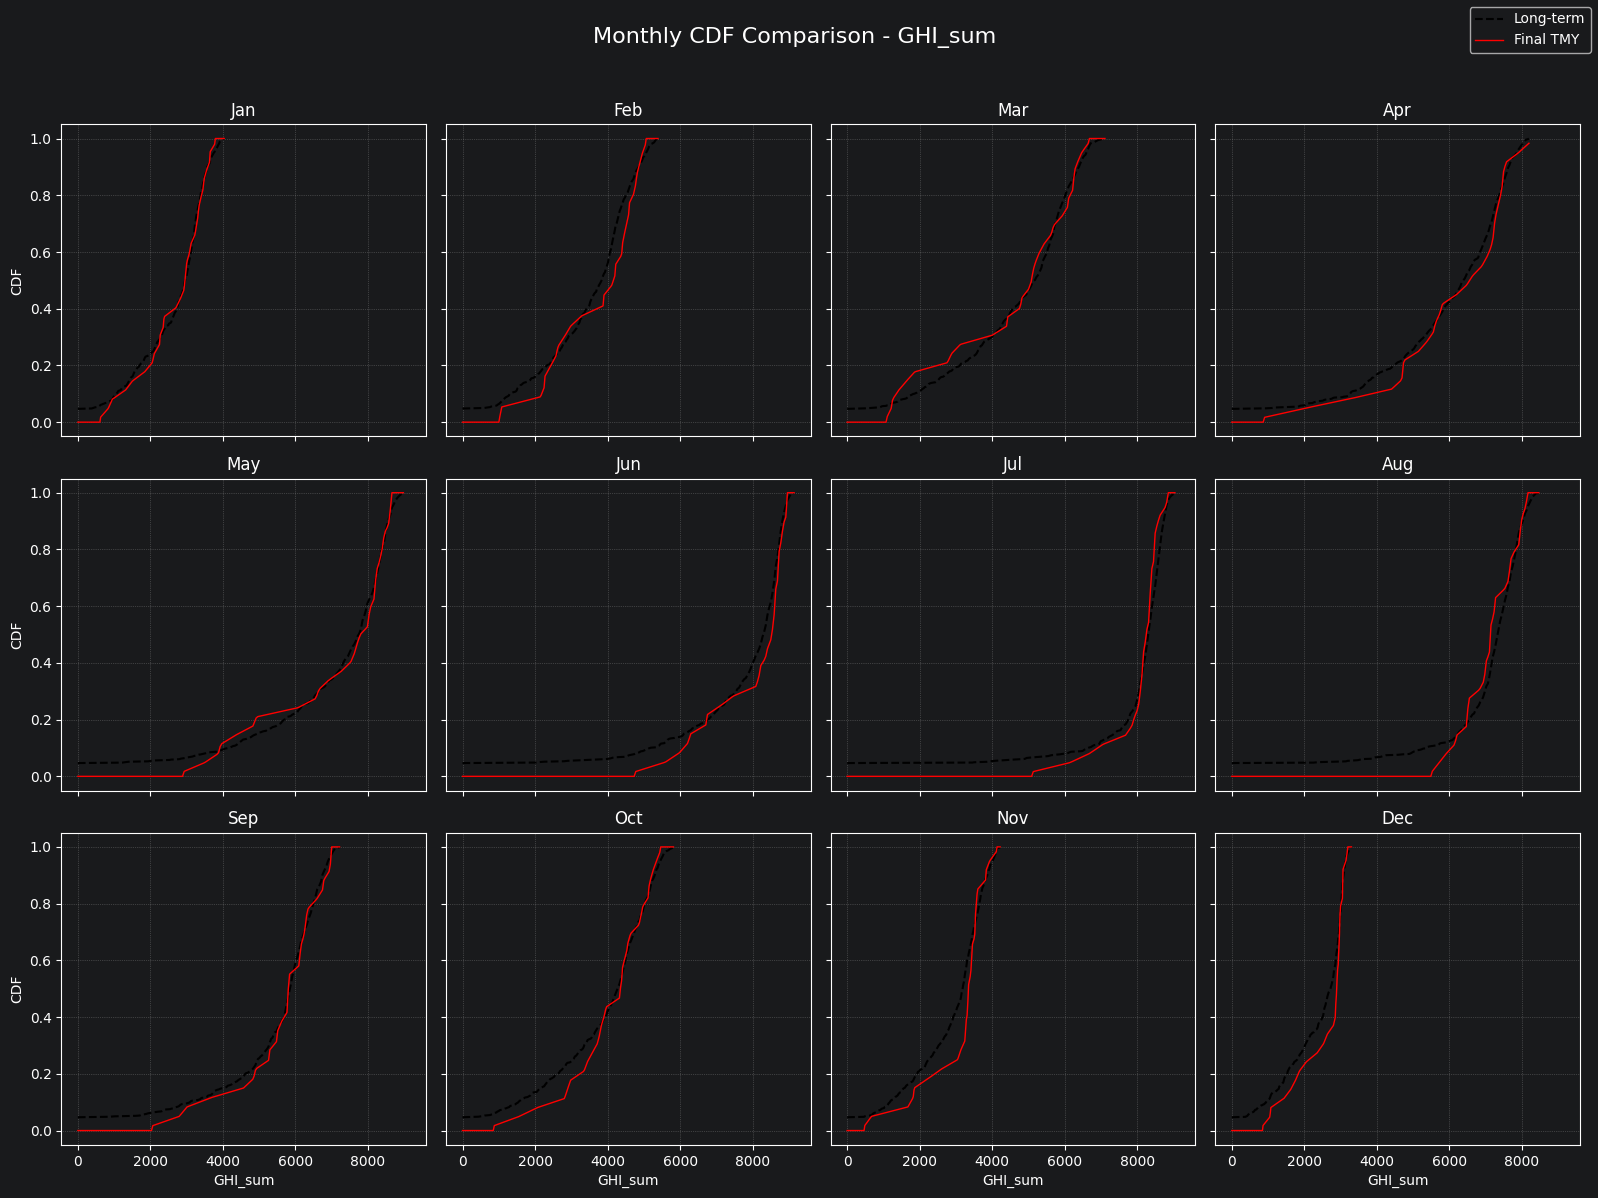

In [32]:
seville_step.plot_monthly_cdfs()

Finally, `correct_selection_by_temperature` offers an optional corrective pass: for any month whose selected year's temperature deviates from the long-term mean by more than `temp_diff_threshold`, it swaps in the Top-5 candidate that minimises that deviation and, since `regenerate=True` (default), re-assembles and re-smooths the TMY in place. `analyze_selection` above already reported zero flagged months for Seville with the standard 1 degC threshold, so we expect an empty corrections dictionary here -- itself a positive validation result, confirming that the automatically selected TMY already matches the long-term mean within 1 degC for every month.

In [33]:
corrections = seville_step.correct_selection_by_temperature(temp_diff_threshold=1.0)


  CORRECTION REPORT  (threshold = |1.0| ﷿﷿C)
  No corrections needed within the specified months.



In [34]:
corrections

{}

`export_tmy` writes the final TMY to disk. Any variable present in `df_hourly` but absent from `tmy_final` is assembled the same way as the TMY and appended, and the original source column names are restored (the inverse of the `col_*` mapping) -- which is exactly what lets `HourlyEPWConverter` (Part 2) consume the exported file directly, without any extra `column_mapping`.

In [35]:
seville_step.export_tmy(os.path.join(OUT_DIR, 'seville_tmy_stepbystep.csv'))

Exporting TMY to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_tmy_stepbystep.csv'...
Export completed successfully.


### Part 1.2 -- Seville: single-call generation and cross-check

`generate_tmy()` runs the same seven steps in a single call. We instantiate a **fresh** `TMYGenerator` (identical constructor arguments to Part 1.1) so the comparison is not influenced by the correction pass just applied above. `use_persistence=True` enables Steps 4-5 (as opposed to falling back to the plain FS ranking), and `persistence_method='sequential'` plus `proximity_normalization_method='std'` match Part 1.1 exactly, so the two runs should select the same twelve typical months. This time we keep the default `save_session=True`, so a reproducible `.pkl`/`.json` session snapshot is written next to the output.

In [36]:
seville_direct = tmy.TMYGenerator(
    file_path=SEVILLE['xlsx'],
    cdf_method='daily',
    data_frequency='hourly',
    hourly_file_path=SEVILLE['xlsx'],
    weighting_method='sandia',
    save_validation_dfs=True,
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

Using 'hazen' plotting position for CDF calculation.


In [37]:
seville_direct = seville_direct.generate_tmy(
    use_persistence=True,
    persistence_method='sequential',
    proximity_normalization_method='std',
)

--- Starting full TMY generation workflow ---
Loading and preparing data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Sevilla_Definitivo_para_convertir_a_epw.xlsx'...
Using all available years in the file: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
Resampling data to hourly frequency and interpolating gaps...
Calculating daily aggregations for weighting method: sandia...
DEBUG: df_daily columns created: ['T_air_mean', 'T_air_max', 'T_air_min', 'T_dew_mean', 'T_dew_max', 'T_dew_min', 'Wind_speed_mean', 'Wind_speed_max', 'GHI_sum']

Loading hourly data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Sevilla_Definitivo_para_convertir_a_epw.xlsx'...
Resampling hourly data and interpolating gaps...


D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:172: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  available_months_in_daily = set(self.df_daily.index.to_period('M'))
D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:176: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_periods = df_hourly_source.index.to_period('M')


Filtering hourly data to only include months available in daily data...
Hourly data loaded successfully with 184080 records.
Real data loaded and prepared.
Step 2: Calculating FS statistics using 'daily' method...
  Month 1: Selected candidates -> [2018, 2013, 2006, 2021, 2025]
  Month 2: Selected candidates -> [2009, 2015, 2016, 2011, 2013]
  Month 3: Selected candidates -> [2011, 2017, 2009, 2010, 2021]
  Month 4: Selected candidates -> [2016, 2008, 2010, 2015, 2013]
  Month 5: Selected candidates -> [2017, 2005, 2023, 2007, 2012]
  Month 6: Selected candidates -> [2022, 2015, 2014, 2021, 2007]
  Month 7: Selected candidates -> [2017, 2013, 2011, 2008, 2014]
  Month 8: Selected candidates -> [2013, 2011, 2005, 2021, 2017]
  Month 9: Selected candidates -> [2013, 2019, 2023, 2021, 2012]
  Month 10: Selected candidates -> [2016, 2013, 2018, 2023, 2008]
  Month 11: Selected candidates -> [2016, 2005, 2011, 2025, 2023]
  Month 12: Selected candidates -> [2005, 2007, 2012, 2023, 2016]
Ste

In [38]:
seville_direct.export_tmy(os.path.join(OUT_DIR, 'seville_tmy_direct.csv'))

Exporting TMY to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_tmy_direct.csv'...
Export completed successfully.


Both runs used the same input data and configuration, so `compare_tmy_versions` should show the step-by-step (pre-correction) and direct results overlapping almost exactly for every month -- any residual difference stems solely from the temperature correction applied at the end of Part 1.1.

D:\Python\pyweatherfiles\pyweatherfiles\tmy\_plotting.py:1202: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


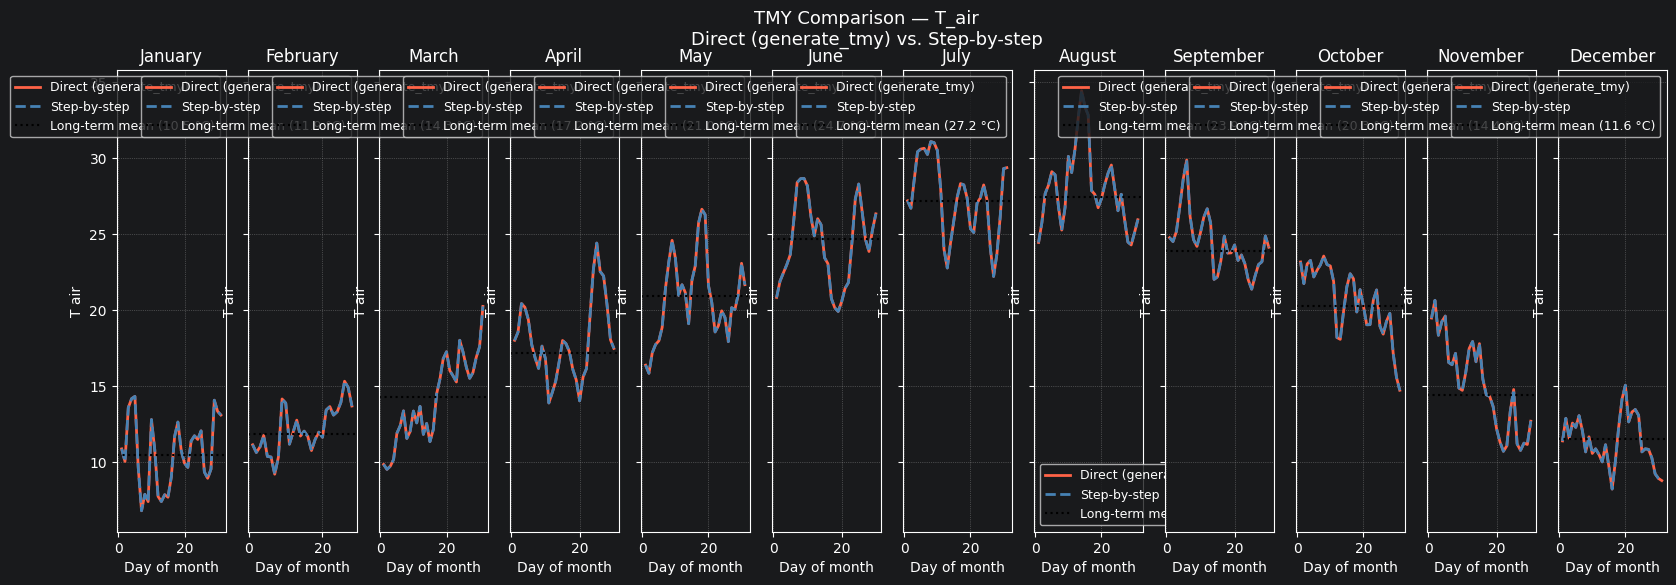

In [39]:
fig_compare_seville = seville_direct.compare_tmy_versions(
    other_tmy_df=seville_step.tmy_final,
    label_self='Direct (generate_tmy)',
    label_other='Step-by-step',
    variable='T_air',
)

### Part 1.3 -- Madrid: condensed single-call generation

We repeat the single-call workflow for Madrid. Its hourly file may use different column headers than Seville's; Part 0's pre-flight check already highlighted any mismatch, so the `column_mapping`/`col_*` arguments below are adjusted accordingly before instantiating the generator.

In [40]:
madrid_tmy_gen = tmy.TMYGenerator(
    file_path=MADRID['xlsx'],
    cdf_method='daily',
    data_frequency='hourly',
    hourly_file_path=MADRID['xlsx'],
    weighting_method='sandia',
    save_validation_dfs=True,
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

Using 'hazen' plotting position for CDF calculation.


In [41]:
madrid_tmy_gen = madrid_tmy_gen.generate_tmy(
    use_persistence=True,
    persistence_method='sequential',
)

--- Starting full TMY generation workflow ---
Loading and preparing data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Madrid_Definitivo_para_convertir_a_epw.xlsx'...
Using all available years in the file: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Resampling data to hourly frequency and interpolating gaps...
Calculating daily aggregations for weighting method: sandia...
DEBUG: df_daily columns created: ['T_air_mean', 'T_air_max', 'T_air_min', 'T_dew_mean', 'T_dew_max', 'T_dew_min', 'Wind_speed_mean', 'Wind_speed_max', 'GHI_sum']

Loading hourly data from 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\Madrid_Definitivo_para_convertir_a_epw.xlsx'...
Resampling hourly data and interpolating gaps...
Filtering hourly data to only include months available in daily data...
Hourly data loaded successfully with 184080 records.
Real data loaded and prepared.
Step 2: Calculating 

D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:172: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  available_months_in_daily = set(self.df_daily.index.to_period('M'))
D:\Python\pyweatherfiles\pyweatherfiles\tmy\_data_loading.py:176: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_periods = df_hourly_source.index.to_period('M')


  Month 1: Selected candidates -> [2013, 2011, 2018, 2023, 2006]
  Month 2: Selected candidates -> [2016, 2015, 2011, 2006, 2009]
  Month 3: Selected candidates -> [2015, 2017, 2014, 2010, 2007]
  Month 4: Selected candidates -> [2022, 2006, 2010, 2015, 2016]
  Month 5: Selected candidates -> [2021, 2024, 2017, 2012, 2007]
  Month 6: Selected candidates -> [2006, 2021, 2020, 2016, 2009]
  Month 7: Selected candidates -> [2021, 2016, 2014, 2010, 2023]
  Month 8: Selected candidates -> [2013, 2008, 2017, 2020, 2019]
  Month 9: Selected candidates -> [2010, 2007, 2008, 2022, 2019]
  Month 10: Selected candidates -> [2018, 2019, 2012, 2016, 2013]
  Month 11: Selected candidates -> [2025, 2010, 2016, 2022, 2012]
  Month 12: Selected candidates -> [2021, 2016, 2017, 2012, 2010]
Step 3: Applying Proximity Ranking to re-order top 5 candidates (method='std')...
  Month 1: Re-ordered by Proximity -> [2013, 2018, 2011, 2023, 2006]
  Month 2: Re-ordered by Proximity -> [2016, 2015, 2011, 2009, 200


--- Plotting Monthly Mean Comparison: Final TMY vs. Long-term ---


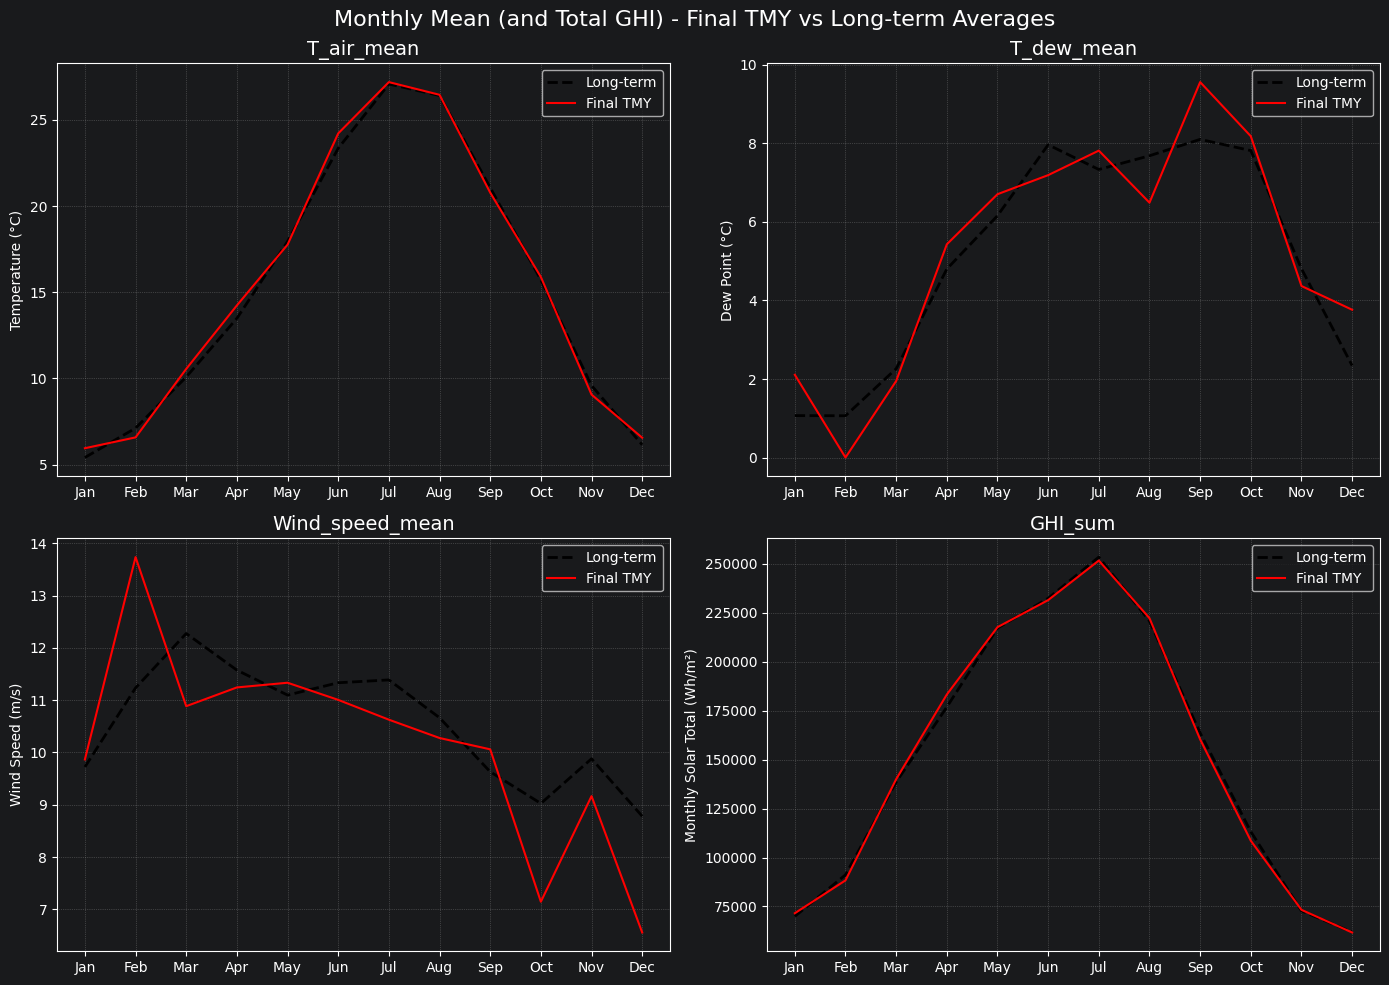

In [42]:
madrid_tmy_gen.plot_monthly_means()

In [43]:
madrid_tmy_gen.export_tmy(os.path.join(OUT_DIR, 'madrid_tmy_direct.csv'))

Exporting TMY to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_tmy_direct.csv'...
Export completed successfully.


## Part 2 -- Conversion to EPW format

Every EPW file produced in this section is written by the **same** converter back-end (`HourlyEPWConverter` for the historical and typical-year scenarios, `met_epw_converter.convert_met_to_epw` for the regulatory scenario) -- the deliberate design choice discussed in Section 2.2.2 of the manuscript, which ensures that any difference observed between scenarios in a downstream simulation is attributable to climatic content rather than to format or conversion artefacts.

```{note}
Unit conventions: `HourlyEPWConverter` assumes input wind speed is in km/h (converted to m/s) and input pressure is in hPa (converted to Pa) -- the units used by the source Excel files here.
```

### Part 2.1 -- Historical scenario: multi-year hourly series to one EPW per year

`HourlyEPWConverter` is instantiated with `file_path` pointing at the raw multi-year hourly Excel file and `base_epw_path` pointing at the city's EPW template (`SEVILLE['base_epw']`), from which latitude, longitude, elevation and time zone are extracted automatically via Ladybug. The `col_*` arguments repeat the column-name mapping already used for the TMY generation in Part 1.

In [44]:
from pyweatherfiles import hourly_epw_converter

seville_hourly_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=SEVILLE['xlsx'],
    base_epw_path=SEVILLE['base_epw'],
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

In [45]:
seville_hourly_converter.available_years

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2021,
 2022,
 2023,
 2024,
 2025]

`process()` writes one EPW file per year found in `available_years` (unless a `years` subset is passed explicitly), naming each file according to `output_pattern`.

In [46]:
seville_hourly_converter.process(output_dir=OUT_DIR, output_pattern='seville_{year}.epw')


--- Processing year 2005 directly ---
Success! Year 2005 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2005.epw

--- Processing year 2006 directly ---
Success! Year 2006 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2006.epw

--- Processing year 2007 directly ---
Success! Year 2007 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2007.epw

--- Processing year 2008 directly ---
Success! Year 2008 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2008.epw

--- Processing year 2009 directly ---
Success! Year 2009 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2009.epw

--- Processing year 2010 directly ---
Success! Year 2010 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_2010.epw

--- Processing year 2011 directly ---
Success! Year

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2021,
 2022,
 2023,
 2024,
 2025]

We repeat the same conversion for Madrid.

In [47]:
madrid_hourly_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=MADRID['xlsx'],
    base_epw_path=MADRID['base_epw'],
    datetime_col='time',
    col_temp='Dry-bulb temperature',
    col_dew='Dew Point temperature',
    col_wind='Wind Speed',
    col_ghi='Global Horizontal Irradiance ',
    col_dni='Beam Normal Irradiance ',
)

In [48]:
madrid_hourly_converter.available_years

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

In [49]:
madrid_hourly_converter.process(output_dir=OUT_DIR, output_pattern='madrid_{year}.epw')


--- Processing year 2005 directly ---
Success! Year 2005 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2005.epw

--- Processing year 2006 directly ---
Success! Year 2006 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2006.epw

--- Processing year 2007 directly ---
Success! Year 2007 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2007.epw

--- Processing year 2008 directly ---
Success! Year 2008 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2008.epw

--- Processing year 2009 directly ---
Success! Year 2009 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2009.epw

--- Processing year 2010 directly ---
Success! Year 2010 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_2010.epw

--- Processing year 2011 directly ---
Success! Year 2011 

[2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

### Part 2.2 -- Typical-year scenario: TMY to final EPW

We reuse `HourlyEPWConverter`, this time pointing `file_path` at the TMY CSV exported in Part 1 (the single-call result: `seville_tmy_direct.csv` / `madrid_tmy_direct.csv`). Because `export_tmy()` already restored the original source column names, **no** `column_mapping` argument is needed here -- the direct payoff of that design choice, highlighted in the docstring of `export_tmy`.

In [50]:
seville_tmy_epw_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=os.path.join(OUT_DIR, 'seville_tmy_direct.csv'), base_epw_path=SEVILLE['base_epw'])

In [51]:
seville_tmy_epw_converter.process(output_dir=OUT_DIR, output_pattern='seville_tmy.epw')


--- Processing year 2000 directly ---
Success! Year 2000 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_tmy.epw
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_seville_tmy_direct_ESP_Sevilla_083910_SWEC_2000_8e77da39.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_seville_tmy_direct_ESP_Sevilla_083910_SWEC_2000_8e77da39.json


[2000]

In [52]:
madrid_tmy_epw_converter = hourly_epw_converter.HourlyEPWConverter(
    file_path=os.path.join(OUT_DIR, 'madrid_tmy_direct.csv'), base_epw_path=MADRID['base_epw'])

In [53]:
madrid_tmy_epw_converter.process(output_dir=OUT_DIR, output_pattern='madrid_tmy.epw')


--- Processing year 2000 directly ---
Success! Year 2000 saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_tmy.epw
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_madrid_tmy_direct_ESP_Madrid_082210_IWEC_2000_f06fe7d9.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\HourlyEPWConverter_madrid_tmy_direct_ESP_Madrid_082210_IWEC_2000_f06fe7d9.json


[2000]

### Part 2.3 -- Regulatory scenario: official `.met` file to EPW

`convert_met_to_epw` is a free function (no class instantiation needed). It reconstructs dew point (Magnus-formula inversion), atmospheric pressure (from absolute humidity, with the barometric formula as a physical fallback), horizontal infrared radiation (Stefan-Boltzmann inversion of the file's sky temperature) and direct normal irradiance (from the direct horizontal component using exact solar geometry, capped at the solar constant). `replace_unused_with_missing=True` fills the 15 EPW fields that EnergyPlus does not use with the format's official missing-value codes rather than zeros. A radiation-balance quality-control check is printed automatically for every conversion.

In [54]:
from pyweatherfiles import met_epw_converter

seville_met_success = met_epw_converter.convert_met_to_epw(
    met_path=SEVILLE['met'],
    base_epw_path=SEVILLE['base_epw'],
    epw_path=os.path.join(OUT_DIR, 'seville_met.epw'),
    replace_unused_with_missing=True,
)

Starting conversion of 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\sevilla_SP.met' to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_met.epw'...
  - Recalculating zenith angle (theta_z) and balancing radiation...
  - QA DNI -> min=0.0, p95=897.2, max=1367.0 W/m2 | low_sun=4630, clipped=13, negative_dir_horiz=0
  - QA balance (GHI - (DHI + DNI*cos(theta_z))) -> abs_mean=0.16 W/m2, abs_p95=0.00 W/m2
MET -> EPW conversion completed (radiation balance ensured)!
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_sevilla_SP_seville_met_ESP_Sevilla_083910_SWEC_670f678b.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_sevilla_SP_seville_met_ESP_Sevilla_083910_SWEC_670f678b.json


In [55]:
madrid_met_success = met_epw_converter.convert_met_to_epw(
    met_path=MADRID['met'],
    base_epw_path=MADRID['base_epw'],
    epw_path=os.path.join(OUT_DIR, 'madrid_met.epw'),
    replace_unused_with_missing=True,
)

Starting conversion of 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\madrid_SP.met' to 'D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\madrid_met.epw'...
  - Recalculating zenith angle (theta_z) and balancing radiation...
  - QA DNI -> min=0.0, p95=865.3, max=1367.0 W/m2 | low_sun=4701, clipped=7, negative_dir_horiz=0
  - QA balance (GHI - (DHI + DNI*cos(theta_z))) -> abs_mean=0.03 W/m2, abs_p95=0.00 W/m2
MET -> EPW conversion completed (radiation balance ensured)!
[SESSION] Pickle saved to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_madrid_SP_madrid_met_ESP_Madrid_082210_IWEC_692947d8.pkl
[SESSION] JSON saved to:    D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\data\convert_met_to_epw_madrid_SP_madrid_met_ESP_Madrid_082210_IWEC_692947d8.json


## Part 3 -- Degree-hours and climate-trend analysis

This section reproduces Section 3.1 of the manuscript ('The climate in Spain: evolution and trend') -- restricted here to the two case-study cities -- using the annual historical EPW files generated in Part 2.1. Three degree-hour indicators are computed for every available year:

1. **Heating degree-hours**, base temperature 20 degC, full day (HDH20).
2. **Cooling degree-hours**, base temperature 25 degC, full day (CDH25).
3. **Night cooling potential**, cooling degree-hours at the same 25 degC base but restricted to the 00:00-08:00 window -- a proxy for how much passive night ventilation can still rely on cool outdoor air.

`pyweatherfiles.degree_hours.EpwGroupTrendAnalyzer` is the class designed for exactly this 'many years, several independent climates, never pooled' analysis; `analysis_scripts/climate_evolution_trend.py` builds the manuscript's Figure 3 on top of the same class over all five study cities. Here we exercise the identical computation over Seville and Madrid only.

### Part 3.1 -- A single-file warm-up (`DegreeHoursCalculator`)

Before scaling up to the full multi-year batch, we introduce `DegreeHoursCalculator` on a single EPW: one representative historical year of Seville. `setpoint_source` is a plain configuration dictionary (`type='constant'`) rather than an IDF path -- the lightweight alternative for climate-only analyses that do not need a full building model.

In [56]:
from pyweatherfiles.degree_hours import DegreeHoursCalculator, EpwGroupTrendAnalyzer

demo_year = seville_hourly_converter.available_years[0]
demo_calc = DegreeHoursCalculator(epw_path=os.path.join(OUT_DIR, f'seville_{demo_year}.epw'))

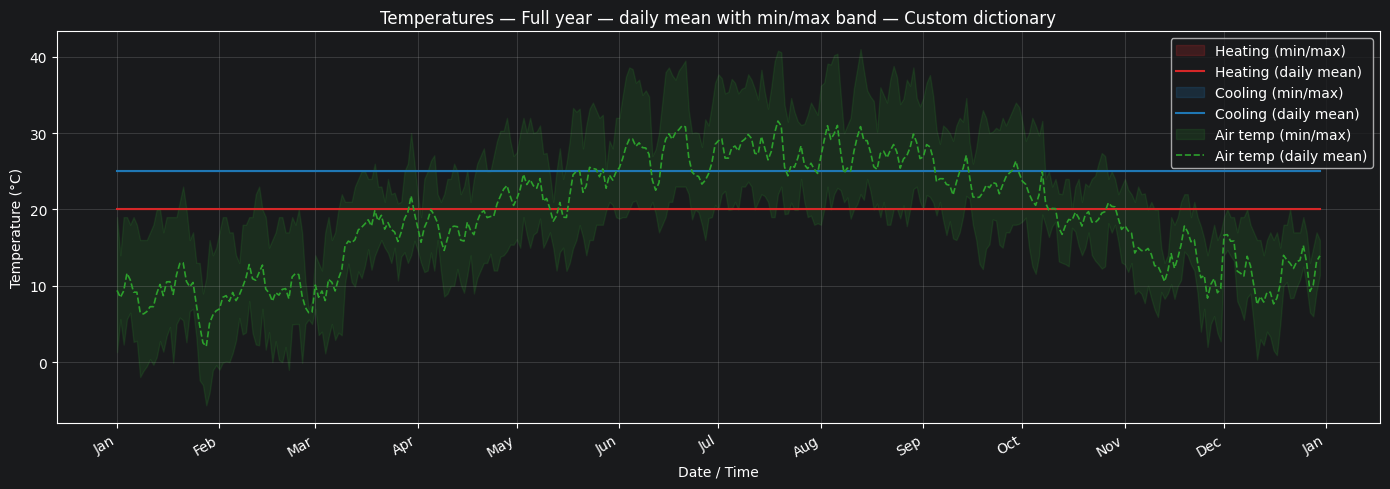

In [57]:
demo_calc.plot(setpoint_source={'type': 'constant', 'heating': 20.0, 'cooling': 25.0},
               period='year', show_air_temp=True)

In [58]:
demo_results = demo_calc.calculate({'type': 'constant', 'heating': 20.0, 'cooling': 25.0},
                                    frequency=['yearly'], mode='both', save_session=False)

[INFO] Calculating degree-hours (mode='both', hours=all, months=all, invert_cooling=False)﷿﷿﷿
[INFO] Calculation completed.
  yearly: (1, 2) -> {'heating_dh': 34755.20280992029, 'cooling_dh': 10860.27026349748}


In [59]:
demo_results['yearly']

,heating_dh,cooling_dh
2000-12-31,34755.20281,10860.270263


### Part 3.2 -- Multi-year batch analysis across both cities

`EpwGroupTrendAnalyzer(epw_dir=...)` scans the Part 2.1 output folder for files matching `filename_pattern` (default `<group>_<year>.epw`, matching the `output_pattern` used above), classifying them into `{city: {year: path}}`. `hours_scenarios` defines the degree-hour scenarios to compute per file -- here, `'allday'` (all 24 hours, both modes) and `'night_0_8h'` (hours 0-7, cooling only, for the night-cooling indicator) -- and `setpoint_source` is the same constant 20/25 degC configuration used in the manuscript. `group_labels`/`group_colors` only affect the display of the two cities in later plots.

In [60]:
HOURS_SCENARIOS = {
    'allday': {'hours': None, 'mode': 'both'},
    'night_potential_jul_sep': {
        'hours': list(range(0, 9)),      # 00:00-08:00 inclusive (9 hourly values)
        'mode': 'cooling',
        'invert_cooling': True,          # degrees MISSING to reach 25 degC (potential), not excess above it
        'months': [7, 8, 9],   # restricted to summer months (Jul-Sep)
    },
}

trend_analyzer = EpwGroupTrendAnalyzer(epw_dir=OUT_DIR,
    setpoint_source={'type': 'constant', 'heating': 20.0, 'cooling': 25.0},
    hours_scenarios=HOURS_SCENARIOS,
    # hours_scenarios={'allday': {'hours': None, 'mode': 'both'},
    #                  'night_0_8h': {'hours': list(range(8)), 'mode': 'cooling'}},
    group_labels={'seville': 'Seville', 'madrid': 'Madrid'})

[WARNING] Filename does not match filename_pattern, skipping: madrid_met.epw
[WARNING] Filename does not match filename_pattern, skipping: madrid_tmy.epw
[WARNING] Filename does not match filename_pattern, skipping: seville_met.epw
[WARNING] Filename does not match filename_pattern, skipping: seville_tmy.epw
[INFO] Classified 41 EPW file(s) into 2 group(s): ['madrid', 'seville']


In [61]:
trend_analyzer.file_groups

{'madrid': {2005: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2005.epw',
  2006: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2006.epw',
  2007: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2007.epw',
  2008: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2008.epw',
  2009: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2009.epw',
  2010: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2010.epw',
  2011: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2011.epw',
  2012: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2012.epw',
  2013: 'D:\\Python\\pyweatherfiles\\docs\\source\\jupyter_notebooks\\case_study_output\\madrid_2013.epw',
  2014: 'D:\\Python\\pyweat

In [62]:
results_df = trend_analyzer.run()

[OK] madrid       2005 -> heating_dh_allday=63836.6, cooling_dh_allday=7891.1, cooling_dh_night_potential_jul_sep=5071.2
[OK] madrid       2006 -> heating_dh_allday=56817.7, cooling_dh_allday=8539.6, cooling_dh_night_potential_jul_sep=4604.7
[OK] madrid       2007 -> heating_dh_allday=63714.9, cooling_dh_allday=5209.6, cooling_dh_night_potential_jul_sep=5588.0
[OK] madrid       2008 -> heating_dh_allday=62379.6, cooling_dh_allday=6321.0, cooling_dh_night_potential_jul_sep=5580.3
[OK] madrid       2009 -> heating_dh_allday=57473.0, cooling_dh_allday=8861.6, cooling_dh_night_potential_jul_sep=4312.5
[OK] madrid       2010 -> heating_dh_allday=65187.5, cooling_dh_allday=6406.3, cooling_dh_night_potential_jul_sep=4729.1
[OK] madrid       2011 -> heating_dh_allday=58331.4, cooling_dh_allday=6547.2, cooling_dh_night_potential_jul_sep=5386.5
[OK] madrid       2012 -> heating_dh_allday=63931.2, cooling_dh_allday=7554.4, cooling_dh_night_potential_jul_sep=5206.6
[OK] madrid       2013 -> heatin

In [63]:
results_df

,group,year,heating_dh_allday,cooling_dh_allday,cooling_dh_night_potential_jul_sep
0,madrid,2005,63836.596127,7891.131553,5071.197718
1,madrid,2006,56817.718541,8539.579740,4604.700000
2,madrid,2007,63714.904655,5209.566758,5588.002353
3,madrid,2008,62379.585172,6321.000000,5580.300000
4,madrid,2009,57473.024665,8861.556915,4312.500000
5,madrid,2010,65187.462866,6406.300000,4729.069998
6,madrid,2011,58331.361699,6547.202067,5386.468343
7,madrid,2012,63931.163157,7554.440015,5206.583303
8,madrid,2013,64404.489890,7324.264333,4449.300000
9,madrid,2014,52275.996457,6335.597150,4754.300000


### Part 3.3 -- Per-city and global trend statistics

`compute_trends(value_col)` fits an independent OLS year-over-year trend per city (never pooled). `fit_global_trend(value_col)` instead fits a **global fixed-effects** model, `value ~ year + C(city)`, sharing the exact estimator used by `EpwTrendAnalyzer.fit_global_model()` (see `pyweatherfiles.trend_stats`) -- the same technique behind the manuscript's pooled/balanced-panel warming-rate estimates in Section 3.1.

In [64]:
trend_analyzer.compute_trends('heating_dh_allday')

,n,slope,intercept,r2,pvalue,significant
group,,,,,,
madrid,21,-328.015093,719961.800183,0.283960,0.012875,True
seville,20,-61.412626,156147.252641,0.027869,0.481761,False


In [65]:
trend_analyzer.compute_trends('cooling_dh_allday')

,n,slope,intercept,r2,pvalue,significant
group,,,,,,
madrid,21,104.914024,-203588.663951,0.259751,0.018271,True
seville,20,124.879702,-240419.716654,0.177972,0.063919,False


In [68]:
trend_analyzer.compute_trends('cooling_dh_night_potential_jul_sep')

,n,slope,intercept,r2,pvalue,significant
group,,,,,,
madrid,21,-46.43009,98244.332324,0.308713,0.008922,True
seville,20,-6.96853,16716.218680,0.010010,0.674711,False


In [69]:
global_night_trend = trend_analyzer.fit_global_trend('cooling_dh_night_potential_jul_sep')

In [70]:
global_night_trend

FixedEffectResult(target='cooling_dh_night_potential_jul_sep', slope_c_per_year=-27.041462027998328, intercept=59176.247020505056, std_error=11.702751104220837, t_stat=-2.3106927411491536, p_value=0.026372610092309623, ci95_low=-50.73244306509734, ci95_high=-3.3504809908993103, r2=0.843771711725964, n_obs=41, n_cities=2, df_resid=38)

### Part 3.4 -- Trend figures: the library's native view and the manuscript-style boxplot

We show two complementary visualisations of the same `results_df`:

- **Library-native**: `plot_overview_grid`, one row per indicator and one column per city, each cell showing that city's own year-by-year bars and OLS trend line (cities are never pooled together).
- **Manuscript-style boxplot**: Figure 3 of the manuscript instead shows, for each indicator, a *boxplot per year* built by pooling that year's values **across cities**, together with a linear trend line fitted to the across-city yearly mean. That specific figure is produced by a short, self-contained plotting routine in `analysis_scripts/climate_evolution_trend.py` (not part of the `pyweatherfiles` public API, since it deliberately pools cities for display purposes only). We reproduce a simplified version of that same routine here, restricted to Seville and Madrid.

```{note}
Both views are shown so that the reader can compare the library's default, never-pool-cities small multiples against the pooled, manuscript-specific boxplot used for Figure 3.
```

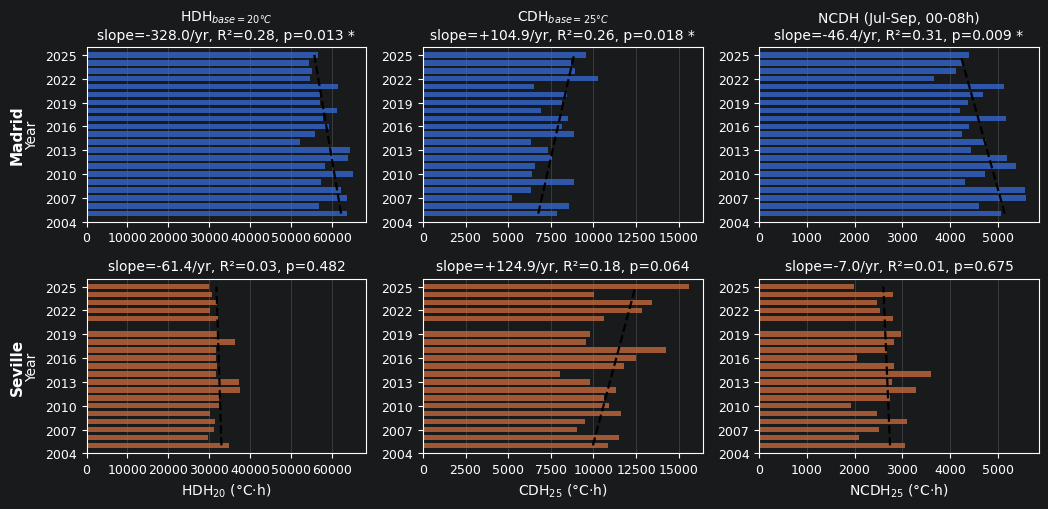

In [73]:
# fig_overview = trend_analyzer.plot_overview_grid(variables=[
#     ('heating_dh_allday', 'HDH20 (degC h)', 'Heating DH'),
#     ('cooling_dh_allday', 'CDH25 (degC h)', 'Cooling DH'),
#     ('cooling_dh_night_0_8h', 'Night CDH25 (degC h)', 'Night cooling potential')], show=True)

fig_overview = trend_analyzer.plot_overview_grid(
        variables=[
            ('heating_dh_allday', 'HDH$_{20}$ (﷿﷿C﷿﷿h)', 'HDH$_{base=20﷿﷿C}$'),
            ('cooling_dh_allday', 'CDH$_{25}$ (﷿﷿C﷿﷿h)', 'CDH$_{base=25﷿﷿C}$'),
            ('cooling_dh_night_potential_jul_sep', 'NCDH$_{25}$ (﷿﷿C﷿﷿h)', 'NCDH (Jul-Sep, 00-08h)'),
        ],
        horizontal=True,
        transpose=True,
        show=True,
        # out_path='fig3_overview_grid_by_city.png',
    )

# continuar aqui

The helper function below mirrors `_boxplot_panel` in `analysis_scripts/climate_evolution_trend.py`: for a given indicator, it draws one box per year (spanning the values of Seville and Madrid that year), overlays the individual city points, and fits a linear trend line to the across-city yearly mean.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


def manuscript_style_boxplot(df, value_col, ylabel, title):
    """One boxplot per year (pooling Seville and Madrid), with a linear
    trend line fitted to the across-city yearly mean. Adapted from
    analysis_scripts/climate_evolution_trend.py's _boxplot_panel()."""
    group_labels = {'seville': 'Seville', 'madrid': 'Madrid'}
    group_colors = {'seville': 'tab:blue', 'madrid': 'tab:red'}
    groups = list(group_labels)

    years = sorted(df['year'].unique())
    data_by_year = [df.loc[df['year'] == y, value_col].dropna().values for y in years]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(
        data_by_year, positions=years, widths=0.6, showfliers=False,
        patch_artist=True, manage_ticks=False,
        boxprops=dict(facecolor='0.85', edgecolor='0.3'),
        medianprops=dict(color='black', linewidth=1.3),
        whiskerprops=dict(color='0.3'), capprops=dict(color='0.3'),
    )

    # Overlay individual city points (small horizontal jitter per city)
    jitter_span = 0.5
    for i, group in enumerate(groups):
        offset = (i - (len(groups) - 1) / 2) * (jitter_span / len(groups))
        sub = df[df['group'] == group]
        ax.scatter(
            sub['year'].values + offset, sub[value_col].values,
            s=28, color=group_colors[group], label=group_labels[group],
            alpha=0.85, zorder=3, edgecolors='white', linewidths=0.4,
        )

    # Trend line fitted to the across-city yearly mean
    yearly_mean = df.groupby('year')[value_col].mean()
    r_mean = stats.linregress(yearly_mean.index.values.astype(float), yearly_mean.values)
    x_line = np.array([min(years), max(years)], dtype=float)
    ax.plot(
        x_line, r_mean.intercept + r_mean.slope * x_line,
        color='crimson', linestyle='--', linewidth=1.8, zorder=4,
        label=f"Trend, both cities: {r_mean.slope:+.1f}/yr (p={r_mean.pvalue:.3f})",
    )

    ax.set_ylabel(ylabel)
    ax.set_xlabel('Year')
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_xlim(min(years) - 1, max(years) + 1)
    ax.legend(loc='best', fontsize=9)
    fig.tight_layout()
    plt.show()
    return fig

In [ ]:
fig_heating_boxplot = manuscript_style_boxplot(results_df, 'heating_dh_allday', 'HDH20 (degC h)',
                                                'Heating degree-hours (T_base = 20 degC, 24 h)')

In [ ]:
fig_cooling_boxplot = manuscript_style_boxplot(results_df, 'cooling_dh_allday', 'CDH25 (degC h)',
                                                'Cooling degree-hours (T_base = 25 degC, 24 h)')

In [ ]:
fig_night_boxplot = manuscript_style_boxplot(results_df, 'cooling_dh_night_0_8h', 'Night CDH25 (degC h)',
                                              'Night cooling potential (T_base = 25 degC, 00:00-08:00 h)')

### Part 3.5 -- Exporting the results

`export_results` writes `results_df` (one sheet) plus every cached `compute_trends` table (one sheet each) to a single Excel workbook when the output path ends in `.xlsx`.

In [74]:
export_path = trend_analyzer.export_results(os.path.join(OUT_DIR, 'seville_madrid_climate_trend.xlsx'))

[INFO] Results exported to: D:\Python\pyweatherfiles\docs\source\jupyter_notebooks\case_study_output\seville_madrid_climate_trend.xlsx


## Part 4 -- Conclusions and further reading

This notebook demonstrated, on real data for two Spanish provincial capitals:

- The complete seven-step Sandia/TMY3 generation pipeline, both as an auditable step-by-step sequence and as a single convenience call, with the two approaches cross-checked against each other.
- The conversion of all three climate scenarios of the manuscript's simulation battery -- historical, typical-year and regulatory -- into a common EPW format via the same converter back-end.
- The degree-hour and climate-trend analysis of Section 3.1 of the manuscript, including the exact global fixed-effects trend estimator shared with `EpwTrendAnalyzer`, restricted here to the two case-study cities.

```{tip}
For the full five-city version of Part 3 (Granada, Leon, Madrid, Malaga, Seville, 2005-2025), see `analysis_scripts/climate_evolution_trend.py`. For the complete API reference of every class and method used above, see `README.md` / `README_ES.md` and `INFORME_REVISION_GENERAL.md`.
```

```{note}
Every main step of Part 1 and every converter call in Parts 2-3 either writes or intentionally skips (`save_session=False`) a reproducible `.pkl`/`.json` session snapshot next to its input/output file, recording the exact parameters used -- see `pyweatherfiles.session_manager` and Section 2.2.2 of the manuscript.
```